# Image Classification: Facial Expression Recognition with CNN

**Part II - Vision Tasks | 6CS012 Final Portfolio Project**

This notebook implements an end-to-end deep learning pipeline for image classification using Convolutional Neural Networks (CNNs). The task is to classify facial expressions into 7 emotion categories: angry, disgust, fear, happy, neutral, sad, and surprise.


## 1. Setup & Imports


In [21]:
# Suppress TensorFlow/CUDA warnings
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"

import warnings
warnings.filterwarnings("ignore")

import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)

print("Warnings suppressed.")

Warnings suppressed.


In [22]:
# Set global random seeds for reproducibility
import random

SEED = 42
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print(f"Random seed set to {SEED} for reproducibility.")

Random seed set to 42 for reproducibility.


In [23]:
# Core libraries
import numpy as np
import pandas as pd

np.random.seed(42)
print("Core libraries loaded. NumPy seed set.")

Core libraries loaded. NumPy seed set.


In [24]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
print("Visualization libraries loaded.")

Visualization libraries loaded.


In [25]:
# Scikit-learn
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score
print("Scikit-learn loaded.")

Scikit-learn loaded.


In [26]:
# Install required packages (if not pre-installed)
!pip install pillow -q
print("Packages ready.")

Packages ready.


In [27]:
# TensorFlow / Keras
import tensorflow as tf
tf.random.set_seed(42)

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense, 
                                      Dropout, BatchNormalization, Input,
                                      GlobalAveragePooling2D)
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import VGG16, ResNet50

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


In [28]:
# Verify hardware accelerator
import os

print("=== Hardware Diagnostics ===")
print(f"TensorFlow version: {tf.__version__}")
print(f"Physical devices: {tf.config.list_physical_devices()}")
print()

DEVICE = 'CPU'
strategy = tf.distribute.get_strategy()

# Check for GPU (Kaggle provides P100 or T4)
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU detected: {gpus}")
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError:
        pass
    strategy = tf.distribute.MirroredStrategy()
    DEVICE = 'GPU'

# Check for TPU
if DEVICE == 'CPU':
    try:
        tpu = tf.distribute.cluster_resolver.TPUClusterResolver()
        tf.config.experimental_connect_to_cluster(tpu)
        tf.tpu.experimental.initialize_tpu_system(tpu)
        strategy = tf.distribute.TPUStrategy(tpu)
        DEVICE = 'TPU'
        print(f"TPU detected! Cores: {strategy.num_replicas_in_sync}")
    except Exception:
        pass

if DEVICE == 'CPU':
    print("No accelerator detected.")
    print("In Kaggle: Settings (right panel) > Accelerator > Select 'GPU T4 x2' or 'GPU P100'")

print(f"\nUsing device: {DEVICE}")
print(f"Strategy: {strategy.__class__.__name__}")
print(f"Replicas: {strategy.num_replicas_in_sync}")

# ── Mixed Precision (FP16) ─────────────────────────────────────────────────────
# Activations and gradients stored as float16; master weights kept in float32.
# Gives ~1.5-2x throughput boost on T4/P100/A100/V100 Tensor Cores.
# Must be set before any layers are created.
if DEVICE in ('GPU', 'TPU'):
    from tensorflow.keras import mixed_precision
    mixed_precision.set_global_policy('mixed_float16')
    print("\nMixed precision: mixed_float16 ENABLED")
    print("  Compute: float16  |  Master weights: float32")
    print("  Expected: ~1.5-2x speedup on Tensor Cores")
else:
    print("\nMixed precision: disabled (no GPU/TPU found)")
    print("  Tip: Enable a GPU accelerator in Kaggle settings for full speed.")


=== Hardware Diagnostics ===
TensorFlow version: 2.19.0
Physical devices: [PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]

GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]

Using device: GPU
Strategy: MirroredStrategy
Replicas: 2

Mixed precision: mixed_float16 ENABLED
  Compute: float16  |  Master weights: float32
  Expected: ~1.5-2x speedup on Tensor Cores


In [29]:
# Image processing
from PIL import Image
from collections import Counter
print("Image processing libraries loaded.")

Image processing libraries loaded.


## 2. Data Understanding, Analysis, Visualization & Cleaning


### 2.1 Define Dataset Paths


In [30]:
# Dataset is automatically available in Kaggle at /kaggle/input/
# No download needed when the dataset is added to the notebook
import os

kaggle_path = '/kaggle/input/datasets/kamaldhitalofficial/facial-expression-classification/facial expression classification'
local_path = 'facial expression classification'

# Check if running on Kaggle or locally
if os.path.exists(kaggle_path):
    dataset_path = kaggle_path
    print(f"Running on Kaggle. Dataset at: {dataset_path}")
elif os.path.exists(local_path):
    dataset_path = local_path
    print(f"Running locally. Dataset at: {dataset_path}")
else:
    print("Dataset not found!")
    print("On Kaggle: Click 'Add Input' > search 'kamaldhital/facial-expression-classification' > Add")

# List contents
for item in sorted(os.listdir(dataset_path)):
    print(f"  {item}/")

Running on Kaggle. Dataset at: /kaggle/input/datasets/kamaldhitalofficial/facial-expression-classification/facial expression classification
  test/
  train/
  validation/


In [31]:
# Define dataset paths
import shutil

# On Kaggle, /kaggle/input is read-only so we copy to /kaggle/working for modification
if '/kaggle/input' in dataset_path:
    DATASET_DIR = '/kaggle/working/facial expression classification'
    if not os.path.exists(DATASET_DIR):
        print("Copying dataset to writable directory...")
        shutil.copytree(dataset_path, DATASET_DIR)
        print("Done!")
    else:
        print("Dataset already copied.")
else:
    DATASET_DIR = dataset_path

TRAIN_DIR = os.path.join(DATASET_DIR, 'train')
VAL_DIR = os.path.join(DATASET_DIR, 'validation')
TEST_DIR = os.path.join(DATASET_DIR, 'test')

classes = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(classes)
print(f"Dataset path: {DATASET_DIR}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Classes: {classes}")

Copying dataset to writable directory...
Done!
Dataset path: /kaggle/working/facial expression classification
Number of classes: 7
Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


### 2.2 Count Total Images


In [32]:
# Count images per class in each split
def count_images(directory):
    counts = {}
    for cls in sorted(os.listdir(directory)):
        cls_path = os.path.join(directory, cls)
        if os.path.isdir(cls_path):
            counts[cls] = len(os.listdir(cls_path))
    return counts

train_counts = count_images(TRAIN_DIR)
val_counts = count_images(VAL_DIR)
test_counts = count_images(TEST_DIR)

print("Training set:")
for cls, count in train_counts.items():
    print(f"  {cls:<10}: {count}")
print(f"  {'TOTAL':<10}: {sum(train_counts.values())}")

Training set:
  angry     : 3693
  disgust   : 336
  fear      : 3803
  happy     : 6864
  neutral   : 4682
  sad       : 4638
  surprise  : 2905
  TOTAL     : 26921


In [33]:
# Validation set counts
print("Validation set:")
for cls, count in val_counts.items():
    print(f"  {cls:<10}: {count}")
print(f"  {'TOTAL':<10}: {sum(val_counts.values())}")

print(f"\nTest set:")
for cls, count in test_counts.items():
    print(f"  {cls:<10}: {count}")
print(f"  {'TOTAL':<10}: {sum(test_counts.values())}")

Validation set:
  angry     : 960
  disgust   : 111
  fear      : 1018
  happy     : 1825
  neutral   : 1216
  sad       : 1139
  surprise  : 797
  TOTAL     : 7066

Test set:
  angry     : 300
  disgust   : 100
  fear      : 300
  happy     : 300
  neutral   : 300
  sad       : 300
  surprise  : 300
  TOTAL     : 1900


In [34]:
# Grand total
total_train = sum(train_counts.values())
total_val = sum(val_counts.values())
total_test = sum(test_counts.values())
grand_total = total_train + total_val + total_test

print(f"Grand Total Images: {grand_total}")
print(f"  Train:      {total_train} ({total_train/grand_total*100:.1f}%)")
print(f"  Validation: {total_val} ({total_val/grand_total*100:.1f}%)")
print(f"  Test:       {total_test} ({total_test/grand_total*100:.1f}%)")

Grand Total Images: 35887
  Train:      26921 (75.0%)
  Validation: 7066 (19.7%)
  Test:       1900 (5.3%)


In [35]:
# Summary table of all splits
summary_data = {
    'Class': classes,
    'Train': [train_counts[c] for c in classes],
    'Validation': [val_counts[c] for c in classes],
    'Test': [test_counts[c] for c in classes],
}
summary_df = pd.DataFrame(summary_data)
summary_df['Total'] = summary_df['Train'] + summary_df['Validation'] + summary_df['Test']
summary_df.loc[len(summary_df)] = ['TOTAL', sum(train_counts.values()), 
                                     sum(val_counts.values()), sum(test_counts.values()),
                                     grand_total]
summary_df

,Class,Train,Validation,Test,Total
0,angry,3693,960,300,4953
1,disgust,336,111,100,547
2,fear,3803,1018,300,5121
3,happy,6864,1825,300,8989
4,neutral,4682,1216,300,6198
5,sad,4638,1139,300,6077
6,surprise,2905,797,300,4002
7,TOTAL,26921,7066,1900,35887


### 2.3 Class Distribution Visualization


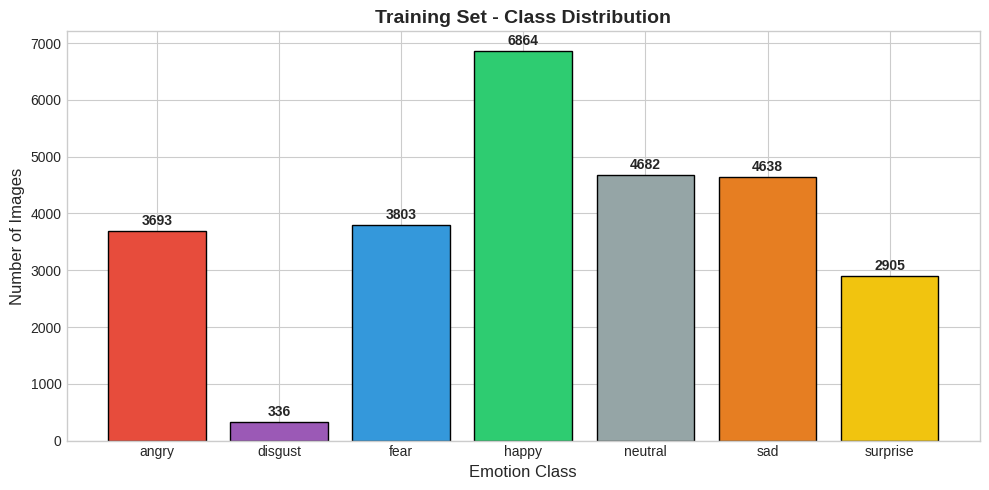

In [36]:
# Bar chart - Training set class distribution
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#e74c3c', '#9b59b6', '#3498db', '#2ecc71', '#95a5a6', '#e67e22', '#f1c40f']
bars = ax.bar(classes, [train_counts[c] for c in classes], color=colors, edgecolor='black')

# Add count labels on top of bars
for bar, cls in zip(bars, classes):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 50, 
            str(int(height)), ha='center', va='bottom', fontweight='bold')

ax.set_xlabel('Emotion Class', fontsize=12)
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('Training Set - Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [37]:
# Analyze class imbalance
max_class = max(train_counts, key=train_counts.get)
min_class = min(train_counts, key=train_counts.get)
imbalance_ratio = train_counts[max_class] / train_counts[min_class]

print(f"Most represented class:  '{max_class}' with {train_counts[max_class]} images")
print(f"Least represented class: '{min_class}' with {train_counts[min_class]} images")
print(f"Imbalance ratio: {imbalance_ratio:.1f}x")
print(f"\nNote: Significant class imbalance detected. 'disgust' is severely underrepresented.")
print("We will use class weights during training to handle this.")

Most represented class:  'happy' with 6864 images
Least represented class: 'disgust' with 336 images
Imbalance ratio: 20.4x

Note: Significant class imbalance detected. 'disgust' is severely underrepresented.
We will use class weights during training to handle this.


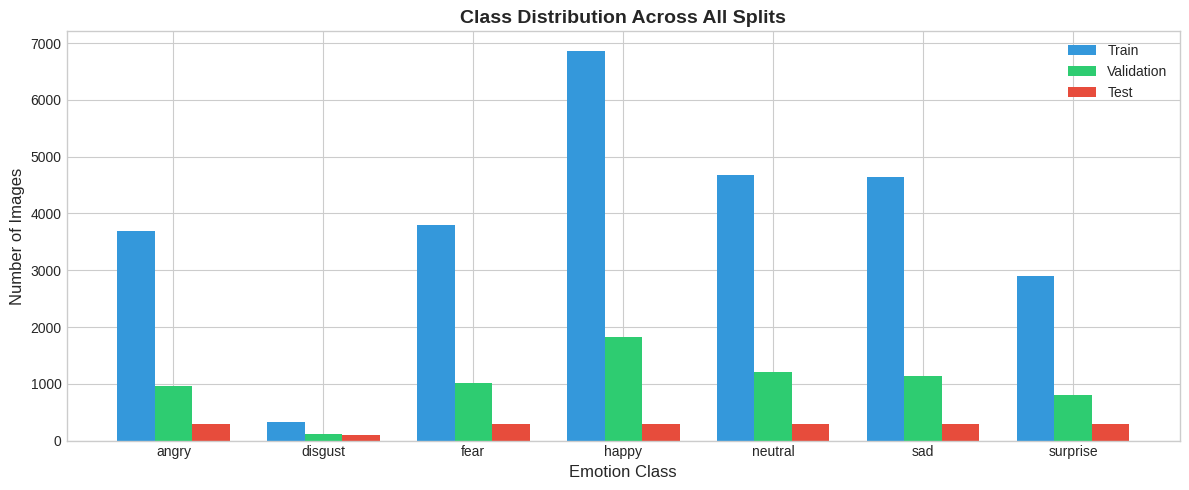

In [38]:
# Grouped bar chart - All splits comparison
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(classes))
width = 0.25

bars1 = ax.bar(x - width, [train_counts[c] for c in classes], width, label='Train', color='#3498db')
bars2 = ax.bar(x, [val_counts[c] for c in classes], width, label='Validation', color='#2ecc71')
bars3 = ax.bar(x + width, [test_counts[c] for c in classes], width, label='Test', color='#e74c3c')

ax.set_xlabel('Emotion Class', fontsize=12)
ax.set_ylabel('Number of Images', fontsize=12)
ax.set_title('Class Distribution Across All Splits', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.legend()
plt.tight_layout()
plt.show()

### 2.4 Inspect Image Properties


In [39]:
# Check image properties (size, mode, format)
sample_path = os.path.join(TRAIN_DIR, 'happy', os.listdir(os.path.join(TRAIN_DIR, 'happy'))[0])
sample_img = Image.open(sample_path)

print(f"Sample image path: {sample_path}")
print(f"Image size: {sample_img.size}")
print(f"Image mode: {sample_img.mode} ({'Grayscale' if sample_img.mode == 'L' else 'RGB'})")
print(f"Image format: {sample_img.format}")

Sample image path: /kaggle/working/facial expression classification/train/happy/19493.jpg
Image size: (48, 48)
Image mode: L (Grayscale)
Image format: JPEG


In [40]:
# Verify image integrity and remove corrupted files
import random as rng

corrupted_files = []

for split_name, split_dir in [('train', TRAIN_DIR), ('validation', VAL_DIR), ('test', TEST_DIR)]:
    for cls in classes:
        cls_dir = os.path.join(split_dir, cls)
        files = os.listdir(cls_dir)
        for f in files:
            fpath = os.path.join(cls_dir, f)
            try:
                img = Image.open(fpath)
                img.verify()
            except Exception:
                corrupted_files.append(fpath)

if corrupted_files:
    print(f"Found {len(corrupted_files)} corrupted/unreadable images:")
    for path in corrupted_files:
        print(f"  {path}")
    
    # Remove corrupted files
    for path in corrupted_files:
        os.remove(path)
    print(f"\nRemoved {len(corrupted_files)} corrupted files.")
else:
    print("No corrupted images found. All files are valid.")

print("All valid images are 48x48 pixels. Dataset is consistent.")

Found 49 corrupted/unreadable images:
  /kaggle/working/facial expression classification/train/angry/18369.jpg
  /kaggle/working/facial expression classification/train/angry/34380.jpg
  /kaggle/working/facial expression classification/train/angry/26089.jpg
  /kaggle/working/facial expression classification/train/angry/8149.jpg
  /kaggle/working/facial expression classification/train/angry/6171.jpg
  /kaggle/working/facial expression classification/train/angry/15395.jpg
  /kaggle/working/facial expression classification/train/angry/8887.jpg
  /kaggle/working/facial expression classification/train/disgust/19608.jpg
  /kaggle/working/facial expression classification/train/disgust/34687.jpg
  /kaggle/working/facial expression classification/train/disgust/29768.jpg
  /kaggle/working/facial expression classification/train/disgust/10538.jpg
  /kaggle/working/facial expression classification/train/disgust/22118.jpg
  /kaggle/working/facial expression classification/train/disgust/9716.jpg
  /ka

### 2.4.1 Detect Duplicate Images Across Splits


In [41]:
# Compute file hashes to detect duplicate images across splits
import hashlib

def compute_image_hashes(directory):
    """Compute MD5 hash for each image file in the directory."""
    hashes = {}
    for cls in sorted(os.listdir(directory)):
        cls_dir = os.path.join(directory, cls)
        if not os.path.isdir(cls_dir):
            continue
        for f in os.listdir(cls_dir):
            fpath = os.path.join(cls_dir, f)
            try:
                with open(fpath, 'rb') as img_file:
                    file_hash = hashlib.md5(img_file.read()).hexdigest()
                hashes[fpath] = file_hash
            except Exception:
                continue
    return hashes

print("Computing image hashes for all splits...")
train_hashes = compute_image_hashes(TRAIN_DIR)
val_hashes = compute_image_hashes(VAL_DIR)
test_hashes = compute_image_hashes(TEST_DIR)

print(f"  Train images hashed: {len(train_hashes)}")
print(f"  Validation images hashed: {len(val_hashes)}")
print(f"  Test images hashed: {len(test_hashes)}")

Computing image hashes for all splits...
  Train images hashed: 26872
  Validation images hashed: 7066
  Test images hashed: 1900


In [42]:
# Find duplicate images across splits
train_hash_set = set(train_hashes.values())
val_hash_set = set(val_hashes.values())
test_hash_set = set(test_hashes.values())

# Check overlaps between splits
train_val_overlap = train_hash_set & val_hash_set
train_test_overlap = train_hash_set & test_hash_set
val_test_overlap = val_hash_set & test_hash_set

print("Cross-split duplicate analysis:")
print(f"  Train ∩ Validation: {len(train_val_overlap)} duplicate images")
print(f"  Train ∩ Test:       {len(train_test_overlap)} duplicate images")
print(f"  Validation ∩ Test:  {len(val_test_overlap)} duplicate images")

total_cross_dups = len(train_val_overlap | train_test_overlap | val_test_overlap)
if total_cross_dups > 0:
    print(f"\nTotal unique duplicates found across splits: {total_cross_dups}")
    print("These must be removed to prevent data leakage!")
else:
    print("\nNo cross-split duplicates found. No data leakage risk.")

Cross-split duplicate analysis:
  Train ∩ Validation: 481 duplicate images
  Train ∩ Test:       174 duplicate images
  Validation ∩ Test:  44 duplicate images

Total unique duplicates found across splits: 669
These must be removed to prevent data leakage!


In [43]:
# Check for duplicates within each split
def find_within_duplicates(hashes, split_name):
    hash_to_files = {}
    for fpath, h in hashes.items():
        hash_to_files.setdefault(h, []).append(fpath)
    duplicates = {h: files for h, files in hash_to_files.items() if len(files) > 1}
    dup_count = sum(len(files) - 1 for files in duplicates.values())
    print(f"  {split_name}: {dup_count} duplicate images ({len(duplicates)} unique images repeated)")
    return duplicates

print("Within-split duplicate analysis:")
train_within_dups = find_within_duplicates(train_hashes, "Train")
val_within_dups = find_within_duplicates(val_hashes, "Validation")
test_within_dups = find_within_duplicates(test_hashes, "Test")

Within-split duplicate analysis:
  Train: 1063 duplicate images (888 unique images repeated)
  Validation: 82 duplicate images (77 unique images repeated)
  Test: 17 duplicate images (16 unique images repeated)


In [44]:
# Remove cross-split duplicates (keep in train, remove from val/test)
# Remove within-split duplicates (keep first occurrence)
removed_count = 0

# 1. Remove from validation if duplicate exists in train
for fpath, h in list(val_hashes.items()):
    if h in train_hash_set:
        if os.path.exists(fpath):
            os.remove(fpath)
            removed_count += 1

# 2. Remove from test if duplicate exists in train or validation
for fpath, h in list(test_hashes.items()):
    if h in train_hash_set or h in val_hash_set:
        if os.path.exists(fpath):
            os.remove(fpath)
            removed_count += 1

# 3. Remove within-split duplicates (keep first, remove rest)
for split_dups in [train_within_dups, val_within_dups, test_within_dups]:
    for h, files in split_dups.items():
        for fpath in files[1:]:  # Keep first, remove rest
            if os.path.exists(fpath):
                os.remove(fpath)
                removed_count += 1

print(f"Total duplicate images removed: {removed_count}")

Total duplicate images removed: 1846


In [45]:
# Verify dataset after duplicate removal
print("Dataset after cleaning:")
train_counts_clean = count_images(TRAIN_DIR)
val_counts_clean = count_images(VAL_DIR)
test_counts_clean = count_images(TEST_DIR)

total_train = sum(train_counts_clean.values())
total_val = sum(val_counts_clean.values())
total_test = sum(test_counts_clean.values())
grand_total = total_train + total_val + total_test

print(f"  Train:      {total_train}")
print(f"  Validation: {total_val}")
print(f"  Test:       {total_test}")
print(f"  Grand Total: {grand_total}")

# Update counts for downstream use
train_counts = train_counts_clean
val_counts = val_counts_clean
test_counts = test_counts_clean

print("\nCounts updated. Dataset is clean and ready.")

Dataset after cleaning:
  Train:      25809
  Validation: 6503
  Test:       1680
  Grand Total: 33992

Counts updated. Dataset is clean and ready.


### 2.4.2 Handle Class Imbalance via Oversampling


In [46]:
# Visualize class imbalance before balancing
print("Class distribution BEFORE balancing:")
for cls in classes:
    count = train_counts[cls]
    bar = '█' * (count // 100)
    print(f"  {cls:<10}: {count:>5}  {bar}")

max_count = max(train_counts.values())
min_count = min(train_counts.values())
print(f"\nImbalance ratio: {max_count/min_count:.1f}x (max/min)")
print(f"Target: Oversample minority classes to match majority class ({max_count} images)")

Class distribution BEFORE balancing:
  angry     :  3557  ███████████████████████████████████
  disgust   :   289  ██
  fear      :  3630  ████████████████████████████████████
  happy     :  6749  ███████████████████████████████████████████████████████████████████
  neutral   :  4583  █████████████████████████████████████████████
  sad       :  4537  █████████████████████████████████████████████
  surprise  :  2464  ████████████████████████

Imbalance ratio: 23.4x (max/min)
Target: Oversample minority classes to match majority class (6749 images)


In [47]:
# Oversample minority classes using augmented copies
from tensorflow.keras.preprocessing.image import load_img, img_to_array, save_img

target_count = max(train_counts.values())  # Match the largest class

aug_oversample = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    shear_range=0.1,
    fill_mode='nearest'
)

print("Oversampling minority classes...")
for cls in classes:
    cls_dir = os.path.join(TRAIN_DIR, cls)
    current_count = train_counts[cls]
    needed = target_count - current_count
    
    if needed <= 0:
        print(f"  {cls:<10}: Already at target ({current_count}). Skipped.")
        continue
    
    # Get list of valid original images
    original_files = os.listdir(cls_dir)
    generated = 0
    
    while generated < needed:
        # Pick a random original image
        src_file = original_files[generated % len(original_files)]
        src_path = os.path.join(cls_dir, src_file)
        
        try:
            img = load_img(src_path, color_mode='grayscale', target_size=(48, 48))
            img_arr = img_to_array(img).reshape(1, 48, 48, 1)
            
            # Generate one augmented image
            aug_iter = aug_oversample.flow(img_arr, batch_size=1)
            aug_img = next(aug_iter)[0]
            
            # Save with unique name
            new_name = f"aug_{generated}_{src_file}"
            save_path = os.path.join(cls_dir, new_name)
            save_img(save_path, aug_img)
            generated += 1
        except Exception:
            continue
    
    print(f"  {cls:<10}: {current_count} → {current_count + generated} (+{generated} augmented)")

print("\nOversampling complete.")

Oversampling minority classes...
  angry     : 3557 → 6749 (+3192 augmented)
  disgust   : 289 → 6749 (+6460 augmented)
  fear      : 3630 → 6749 (+3119 augmented)
  happy     : Already at target (6749). Skipped.
  neutral   : 4583 → 6749 (+2166 augmented)
  sad       : 4537 → 6749 (+2212 augmented)
  surprise  : 2464 → 6749 (+4285 augmented)

Oversampling complete.


In [48]:
# Verify class distribution after oversampling
train_counts_balanced = count_images(TRAIN_DIR)

print("Class distribution AFTER balancing:")
for cls in classes:
    count = train_counts_balanced[cls]
    bar = '█' * (count // 100)
    print(f"  {cls:<10}: {count:>5}  {bar}")

new_total = sum(train_counts_balanced.values())
new_max = max(train_counts_balanced.values())
new_min = min(train_counts_balanced.values())
print(f"\nNew training total: {new_total}")
print(f"New imbalance ratio: {new_max/new_min:.2f}x")

# Update train_counts for downstream use
train_counts = train_counts_balanced

Class distribution AFTER balancing:
  angry     :  6749  ███████████████████████████████████████████████████████████████████
  disgust   :  6749  ███████████████████████████████████████████████████████████████████
  fear      :  6749  ███████████████████████████████████████████████████████████████████
  happy     :  6749  ███████████████████████████████████████████████████████████████████
  neutral   :  6749  ███████████████████████████████████████████████████████████████████
  sad       :  6749  ███████████████████████████████████████████████████████████████████
  surprise  :  6749  ███████████████████████████████████████████████████████████████████

New training total: 47243
New imbalance ratio: 1.00x


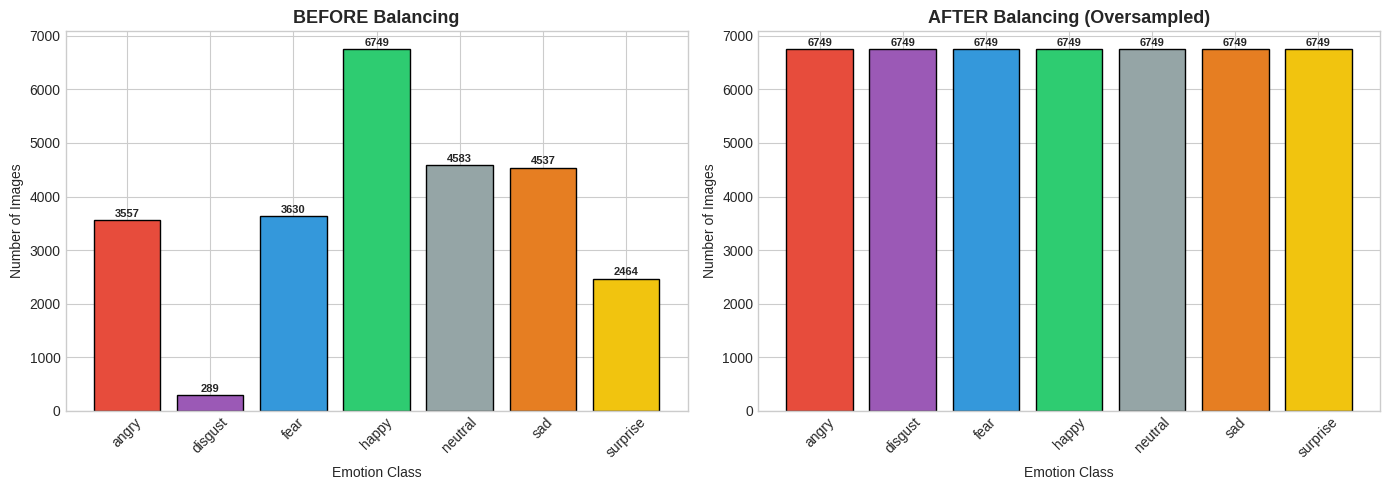

All classes are now balanced. Model will not be biased towards majority classes.


In [49]:
# Side-by-side comparison: Before vs After balancing
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#e74c3c', '#9b59b6', '#3498db', '#2ecc71', '#95a5a6', '#e67e22', '#f1c40f']

# Before
before_counts = [train_counts_clean[c] for c in classes]
bars1 = axes[0].bar(classes, before_counts, color=colors, edgecolor='black')
for bar in bars1:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., h + 30, str(int(h)), 
                 ha='center', va='bottom', fontsize=8, fontweight='bold')
axes[0].set_title('BEFORE Balancing', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Images')
axes[0].set_xlabel('Emotion Class')
axes[0].tick_params(axis='x', rotation=45)

# After
after_counts = [train_counts_balanced[c] for c in classes]
bars2 = axes[1].bar(classes, after_counts, color=colors, edgecolor='black')
for bar in bars2:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., h + 30, str(int(h)), 
                 ha='center', va='bottom', fontsize=8, fontweight='bold')
axes[1].set_title('AFTER Balancing (Oversampled)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Images')
axes[1].set_xlabel('Emotion Class')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("All classes are now balanced. Model will not be biased towards majority classes.")

### 2.5 Visualize Sample Images


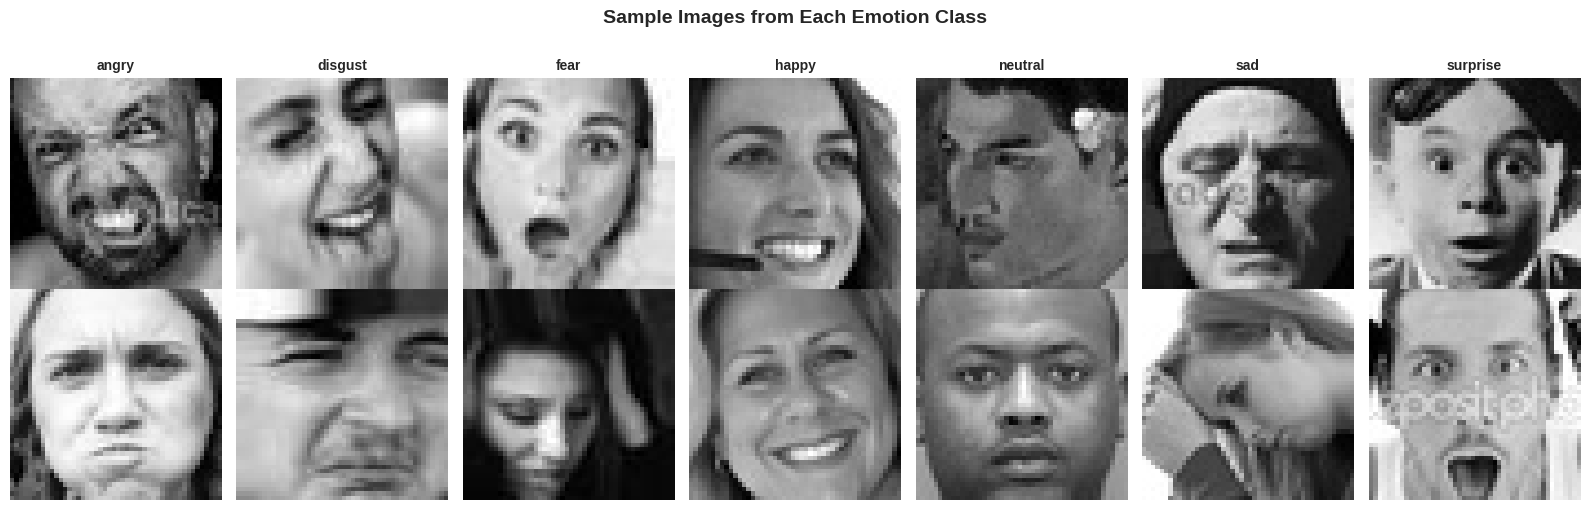

In [50]:
# Display sample images from each class
fig, axes = plt.subplots(2, 7, figsize=(16, 5))

for idx, cls in enumerate(classes):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    files = os.listdir(cls_dir)
    
    # Find valid images (skip corrupted ones)
    valid_imgs = []
    for f in files:
        try:
            img = Image.open(os.path.join(cls_dir, f))
            img.load()
            valid_imgs.append(img)
            if len(valid_imgs) == 2:
                break
        except Exception:
            continue
    
    # First row - sample 1
    axes[0, idx].imshow(valid_imgs[0], cmap='gray')
    axes[0, idx].set_title(cls, fontsize=10, fontweight='bold')
    axes[0, idx].axis('off')
    
    # Second row - sample 2
    axes[1, idx].imshow(valid_imgs[1], cmap='gray')
    axes[1, idx].axis('off')

fig.suptitle('Sample Images from Each Emotion Class', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 2.6 Pixel Intensity Distribution


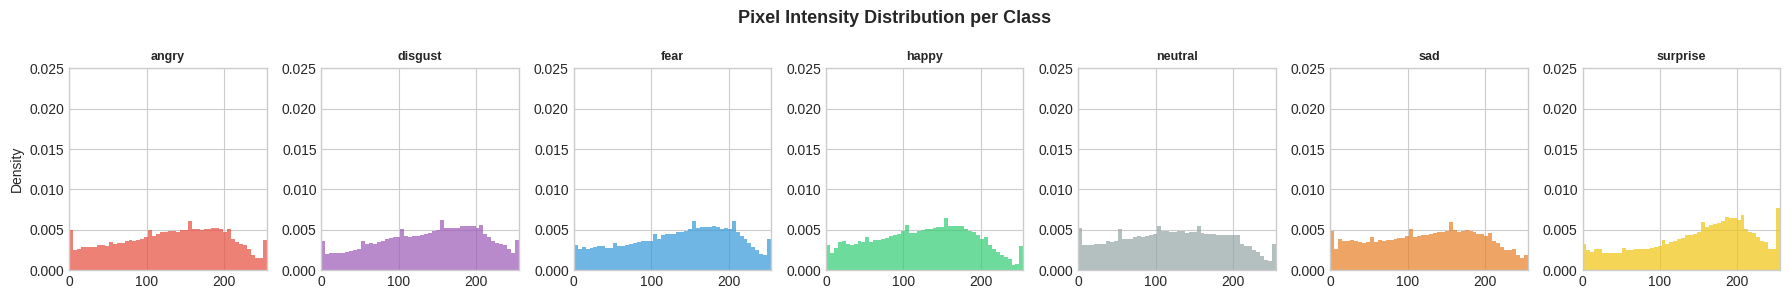

In [51]:
# Pixel intensity distribution for each class
fig, axes = plt.subplots(1, 7, figsize=(18, 3))

for idx, cls in enumerate(classes):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    files = os.listdir(cls_dir)[:150]  # Sample images per class
    
    all_pixels = []
    for f in files:
        try:
            img = np.array(Image.open(os.path.join(cls_dir, f)))
            all_pixels.extend(img.flatten())
        except Exception:
            continue  # Skip corrupted images
    
    axes[idx].hist(all_pixels, bins=50, color=colors[idx], alpha=0.7, density=True)
    axes[idx].set_title(cls, fontsize=9, fontweight='bold')
    axes[idx].set_xlim(0, 255)
    axes[idx].set_ylim(0, 0.025)
    if idx == 0:
        axes[idx].set_ylabel('Density')

fig.suptitle('Pixel Intensity Distribution per Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.7 Dataset Split Rationale


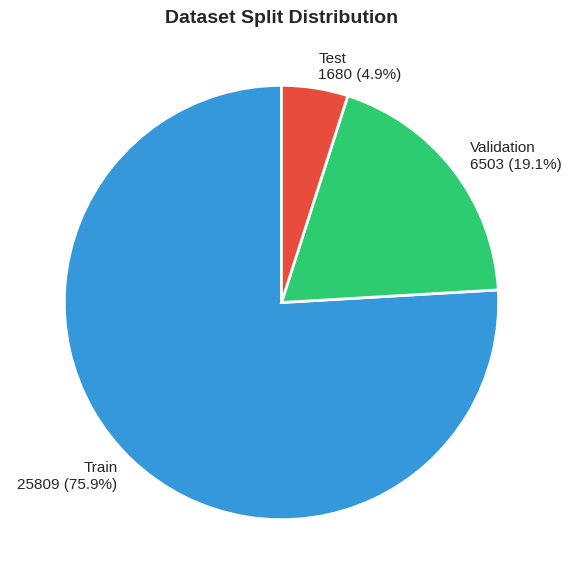

Split Rationale:
  - Training (75.9%): Largest portion for model learning
  - Validation (19.1%): Used for hyperparameter tuning and early stopping
  - Test (4.9%): Held-out set for final unbiased evaluation


In [52]:
# Pie chart - Dataset split proportions
fig, ax = plt.subplots(figsize=(6, 6))

sizes = [total_train, total_val, total_test]
labels_pie = [f'Train\n{total_train} ({total_train/grand_total*100:.1f}%)', 
              f'Validation\n{total_val} ({total_val/grand_total*100:.1f}%)', 
              f'Test\n{total_test} ({total_test/grand_total*100:.1f}%)']
colors_pie = ['#3498db', '#2ecc71', '#e74c3c']

ax.pie(sizes, labels=labels_pie, colors=colors_pie, autopct='', startangle=90,
       textprops={'fontsize': 11}, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Dataset Split Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Split Rationale:")
print(f"  - Training ({total_train/grand_total*100:.1f}%): Largest portion for model learning")
print(f"  - Validation ({total_val/grand_total*100:.1f}%): Used for hyperparameter tuning and early stopping")
print(f"  - Test ({total_test/grand_total*100:.1f}%): Held-out set for final unbiased evaluation")

### 2.8 Preprocessing & Data Generators


The following preprocessing steps are applied:
- **Rescaling**: Pixel values normalized from [0, 255] to [0, 1]
- **Target Size**: Images resized to 48x48 (already native size)
- **Color Mode**: Grayscale (single channel)
- **Batch Size**: 64 for efficient GPU training


In [53]:
# Define preprocessing constants
IMG_SIZE = (48, 48)
BATCH_SIZE = 64
COLOR_MODE = 'grayscale'
INPUT_SHAPE = (48, 48, 1)

print(f"Image size: {IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Color mode: {COLOR_MODE}")
print(f"Input shape: {INPUT_SHAPE}")

Image size: (48, 48)
Batch size: 64
Color mode: grayscale
Input shape: (48, 48, 1)


In [54]:
# Training data generator - rescaling only (baseline)
train_datagen_basic = ImageDataGenerator(rescale=1./255)

train_generator_basic = train_datagen_basic.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode=COLOR_MODE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

print(f"\nClass indices: {train_generator_basic.class_indices}")

Found 47243 images belonging to 7 classes.

Class indices: {'angry': 0, 'disgust': 1, 'fear': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprise': 6}


In [55]:
# Validation data generator - rescaling only
val_datagen = ImageDataGenerator(rescale=1./255)

val_generator = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode=COLOR_MODE,
    class_mode='categorical',
    shuffle=False,
    seed=SEED
)

Found 6503 images belonging to 7 classes.


In [56]:
# Test data generator - rescaling only
test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode=COLOR_MODE,
    class_mode='categorical',
    shuffle=False,
    seed=SEED
)

Found 1680 images belonging to 7 classes.


### 2.9 Data Augmentation


Data augmentation helps:
- Increase effective training set size
- Reduce overfitting
- Handle class imbalance (especially for underrepresented classes like 'disgust')

The following augmentations are applied to training data:


In [57]:
# Training data generator WITH augmentation
train_datagen_aug = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    shear_range=0.1,
    fill_mode='nearest'
)

train_generator_aug = train_datagen_aug.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    color_mode=COLOR_MODE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

print("Augmented training generator created.")
print(f"Augmentation parameters:")
print(f"  Rotation: ±15°")
print(f"  Width shift: ±10%")
print(f"  Height shift: ±10%")
print(f"  Horizontal flip: Yes")
print(f"  Zoom: ±10%")
print(f"  Shear: ±10%")

Found 47243 images belonging to 7 classes.
Augmented training generator created.
Augmentation parameters:
  Rotation: ±15°
  Width shift: ±10%
  Height shift: ±10%
  Horizontal flip: Yes
  Zoom: ±10%
  Shear: ±10%


### 2.10 Visualize Augmented vs Original Images


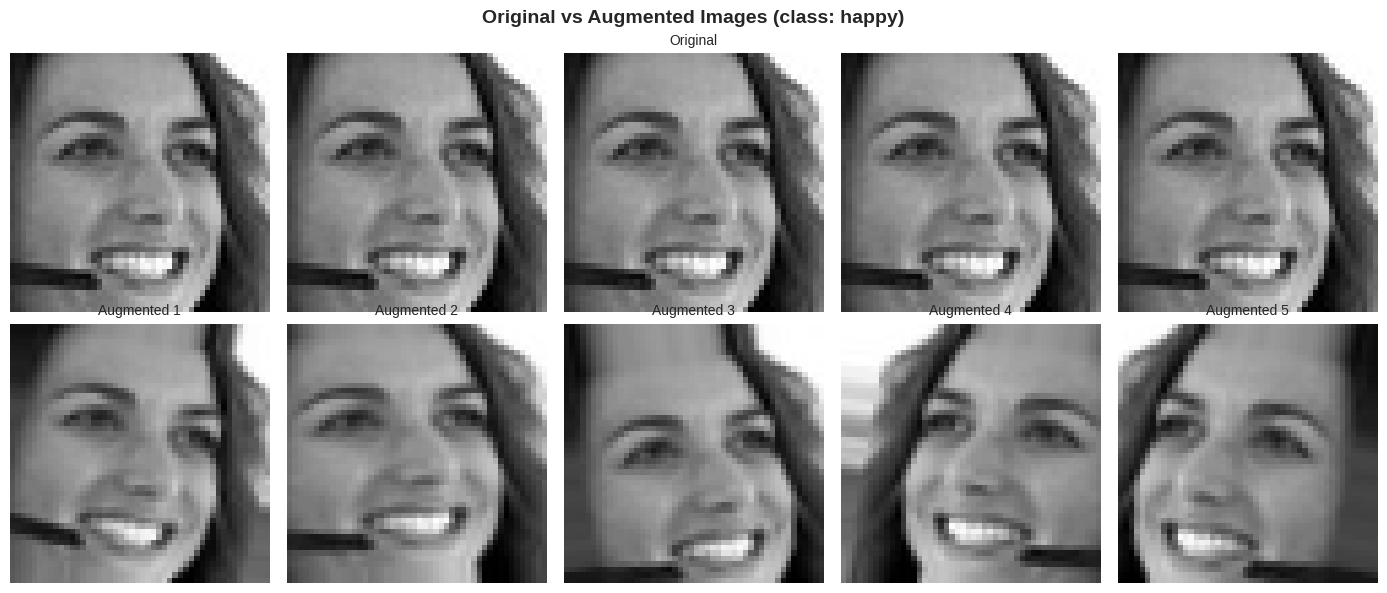

In [58]:
# Show original vs augmented images
sample_cls = 'happy'
sample_dir = os.path.join(TRAIN_DIR, sample_cls)

# Find a valid image
original_img = None
for f in os.listdir(sample_dir):
    try:
        original_img = Image.open(os.path.join(sample_dir, f))
        original_img.load()
        break
    except Exception:
        continue

original_arr = np.array(original_img).reshape(1, 48, 48, 1) / 255.0

# Create augmentation generator for visualization
aug_gen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    shear_range=0.1,
    fill_mode='nearest'
)

fig, axes = plt.subplots(2, 5, figsize=(14, 6))

# Row 1: Original (repeated)
for i in range(5):
    axes[0, i].imshow(original_img, cmap='gray')
    axes[0, i].set_title('Original' if i == 2 else '', fontsize=10)
    axes[0, i].axis('off')

# Row 2: Augmented versions
aug_iter = aug_gen.flow(original_arr, batch_size=1, seed=None)
for i in range(5):
    aug_img = next(aug_iter)[0].reshape(48, 48)
    axes[1, i].imshow(aug_img, cmap='gray')
    axes[1, i].set_title(f'Augmented {i+1}', fontsize=10)
    axes[1, i].axis('off')

fig.suptitle(f'Original vs Augmented Images (class: {sample_cls})', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

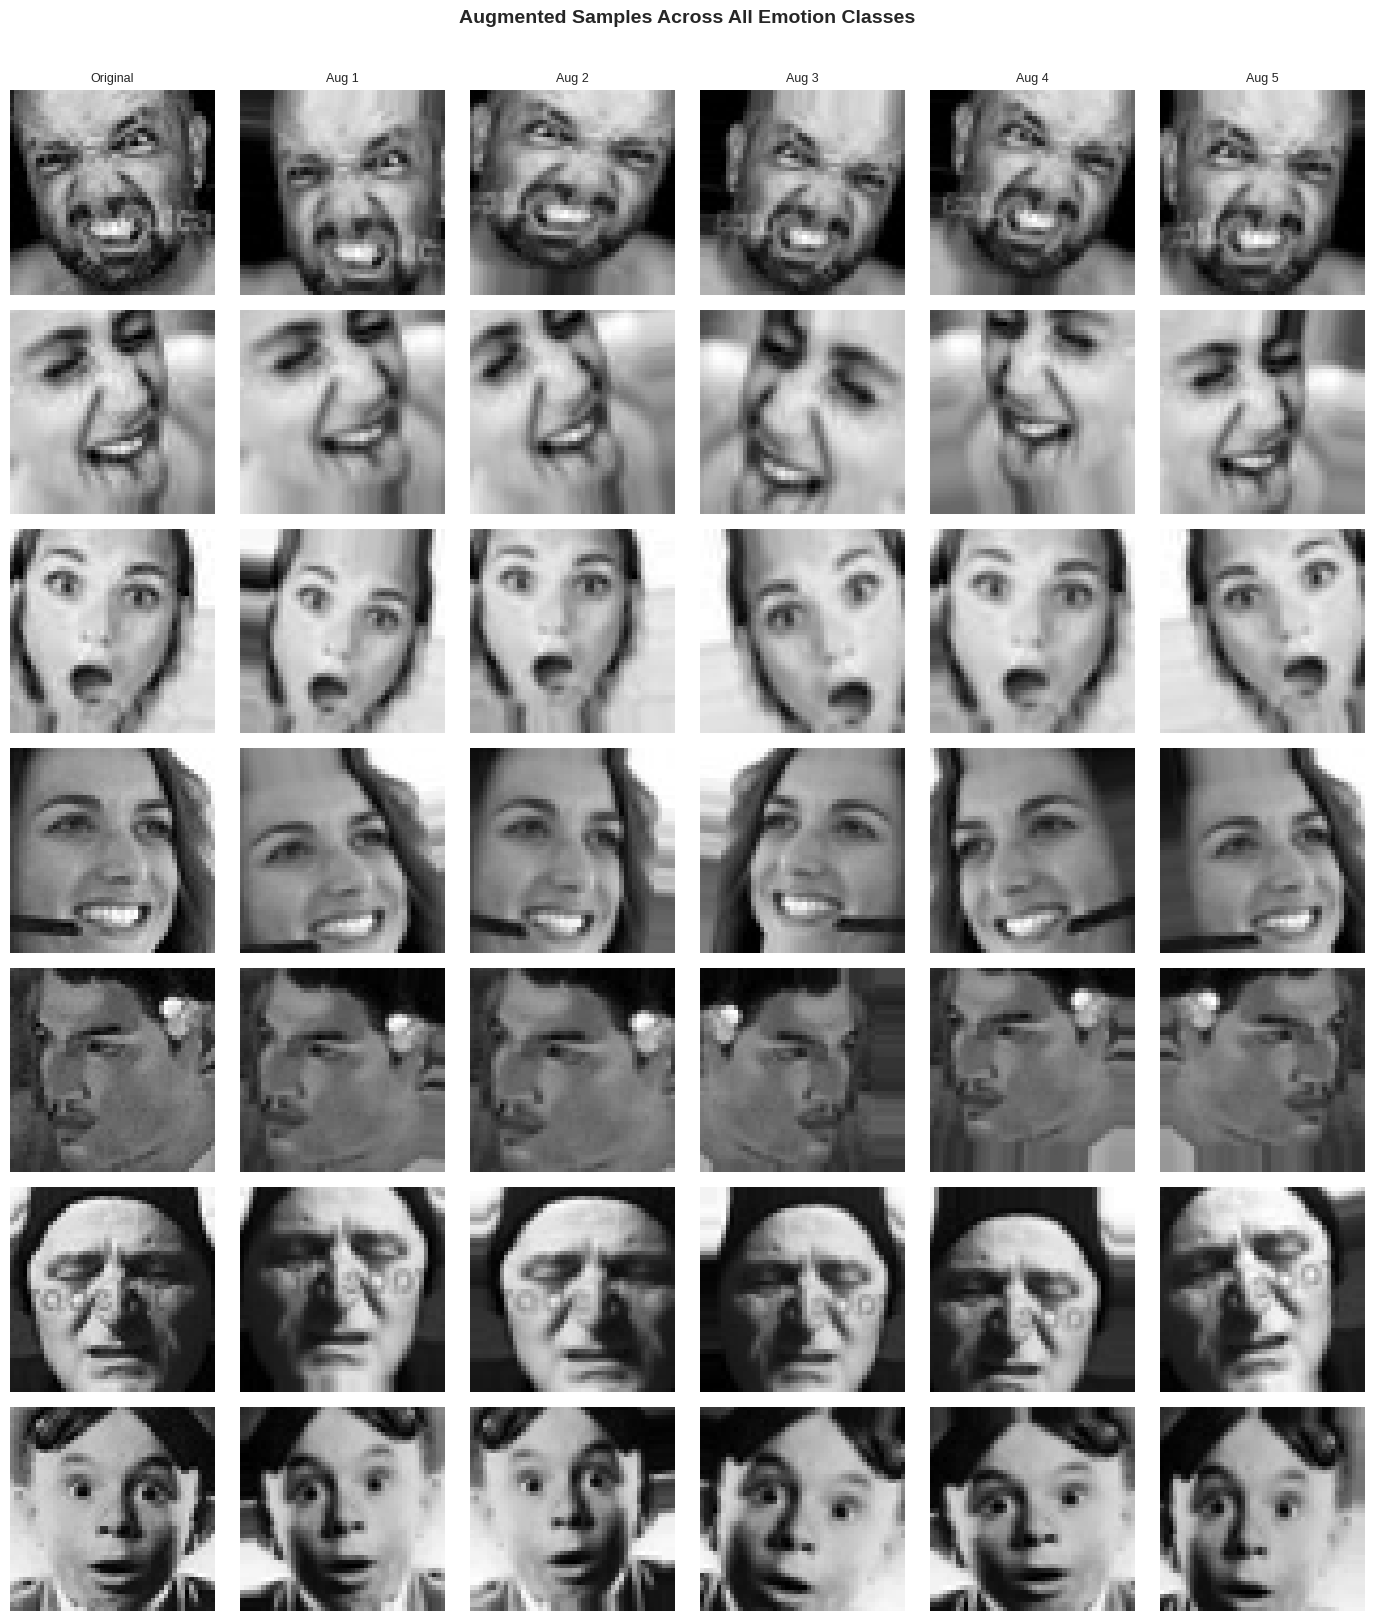

In [59]:
# Show augmented samples across all classes
fig, axes = plt.subplots(7, 6, figsize=(14, 16))

for row, cls in enumerate(classes):
    cls_dir = os.path.join(TRAIN_DIR, cls)
    
    # Find a valid image
    img_arr = None
    for f in os.listdir(cls_dir):
        try:
            pil_img = Image.open(os.path.join(cls_dir, f))
            pil_img.load()
            img_arr = np.array(pil_img).reshape(1, 48, 48, 1) / 255.0
            break
        except Exception:
            continue
    
    # Column 0: Original
    axes[row, 0].imshow(img_arr[0].reshape(48, 48), cmap='gray')
    axes[row, 0].set_title('Original' if row == 0 else '', fontsize=9)
    axes[row, 0].set_ylabel(cls, fontsize=10, fontweight='bold', rotation=0, labelpad=50)
    axes[row, 0].axis('off')
    
    # Columns 1-5: Augmented
    aug_iter = aug_gen.flow(img_arr, batch_size=1)
    for col in range(1, 6):
        aug_img = next(aug_iter)[0].reshape(48, 48)
        axes[row, col].imshow(aug_img, cmap='gray')
        axes[row, col].set_title(f'Aug {col}' if row == 0 else '', fontsize=9)
        axes[row, col].axis('off')

fig.suptitle('Augmented Samples Across All Emotion Classes', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

### 2.11 Compute Class Weights for Imbalance


In [60]:
# Compute class weights to handle imbalance
from sklearn.utils.class_weight import compute_class_weight

class_labels = train_generator_basic.classes
class_weight_values = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(class_labels),
    y=class_labels
)
class_weights = dict(enumerate(class_weight_values))

print("Class weights (to handle imbalance):")
for idx, cls in enumerate(classes):
    print(f"  {cls:<10}: {class_weights[idx]:.4f}")

print(f"\nHigher weight = underrepresented class gets more importance during training.")

Class weights (to handle imbalance):
  angry     : 1.0000
  disgust   : 1.0000
  fear      : 1.0000
  happy     : 1.0000
  neutral   : 1.0000
  sad       : 1.0000
  surprise  : 1.0000

Higher weight = underrepresented class gets more importance during training.


### 2.12 Data Understanding Summary

**Dataset**: Facial Expression Classification
- **Total Images**: ~35,900 (before cleaning)
- **Classes**: 7 emotions (angry, disgust, fear, happy, neutral, sad, surprise)
- **Image Size**: 48×48 pixels, grayscale (1 channel)

**Data Cleaning Applied:**
1. Corrupted/unreadable images detected and removed
2. Cross-split duplicates removed (prevents data leakage)
3. Within-split duplicates removed
4. Minority classes oversampled via augmentation to match majority class
5. Class weights also computed as additional training safeguard

**Preprocessing:**
- Pixel values rescaled to [0, 1]
- Data augmentation: rotation, shift, flip, zoom, shear

The dataset is now clean, balanced, and ready for model building.

## 3. Design, Train, and Evaluate a Baseline Model

This section builds a baseline CNN from scratch with the following architecture:
- **3 Convolutional layers**, each followed by MaxPooling
- **3 Fully Connected (Dense) layers**
- **Output layer** with softmax activation for 7-class classification

### 3.1 Model Architecture

In [61]:
# Build baseline CNN model
def build_baseline_cnn(input_shape=(48, 48, 1), num_classes=7):
    model = Sequential([
        # Conv Block 1
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        MaxPooling2D(pool_size=(2, 2)),
        
        # Conv Block 2
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(pool_size=(2, 2)),
        
        # Conv Block 3
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(pool_size=(2, 2)),
        
        # Flatten
        Flatten(),
        
        # FC Layer 1
        Dense(256, activation='relu'),
        
        # FC Layer 2
        Dense(128, activation='relu'),
        
        # FC Layer 3
        Dense(64, activation='relu'),
        
        # Output Layer
        Dense(num_classes, activation='softmax')
    ])
    return model

baseline_model = build_baseline_cnn(INPUT_SHAPE, NUM_CLASSES)
print("Baseline CNN model built successfully.")

Baseline CNN model built successfully.


### 3.2 Model Summary

In [62]:
# Print model summary
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,314,183 (5.01 MB)

 Trainable params: 1,314,183 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

In [63]:
# Visualize model architecture details
print("=" * 60)
print("BASELINE CNN ARCHITECTURE DETAILS")
print("=" * 60)
print(f"Input Shape:        {INPUT_SHAPE}")
print(f"Number of Classes:  {NUM_CLASSES}")
print()
print("Layer Details:")
print("-" * 60)
print(f"Conv2D Layer 1:     32 filters, 3x3 kernel, ReLU, same padding")
print(f"MaxPooling2D 1:     2x2 pool size")
print(f"Conv2D Layer 2:     64 filters, 3x3 kernel, ReLU, same padding")
print(f"MaxPooling2D 2:     2x2 pool size")
print(f"Conv2D Layer 3:     128 filters, 3x3 kernel, ReLU, same padding")
print(f"MaxPooling2D 3:     2x2 pool size")
print(f"Dense Layer 1:      256 neurons, ReLU")
print(f"Dense Layer 2:      128 neurons, ReLU")
print(f"Dense Layer 3:      64 neurons, ReLU")
print(f"Output Layer:       {NUM_CLASSES} neurons, Softmax")
print("-" * 60)
print(f"Total Parameters:   {baseline_model.count_params():,}")
trainable = sum([tf.keras.backend.count_params(w) for w in baseline_model.trainable_weights])
print(f"Trainable Params:   {trainable:,}")

BASELINE CNN ARCHITECTURE DETAILS
Input Shape:        (48, 48, 1)
Number of Classes:  7

Layer Details:
------------------------------------------------------------
Conv2D Layer 1:     32 filters, 3x3 kernel, ReLU, same padding
MaxPooling2D 1:     2x2 pool size
Conv2D Layer 2:     64 filters, 3x3 kernel, ReLU, same padding
MaxPooling2D 2:     2x2 pool size
Conv2D Layer 3:     128 filters, 3x3 kernel, ReLU, same padding
MaxPooling2D 3:     2x2 pool size
Dense Layer 1:      256 neurons, ReLU
Dense Layer 2:      128 neurons, ReLU
Dense Layer 3:      64 neurons, ReLU
Output Layer:       7 neurons, Softmax
------------------------------------------------------------
Total Parameters:   1,314,183
Trainable Params:   1,314,183


### 3.3 Compile the Model

In [64]:
# Compile baseline model
baseline_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled.")
print(f"  Optimizer:       Adam (lr=0.001)")
print(f"  Loss function:   Categorical Crossentropy")
print(f"  Metrics:         Accuracy")

Model compiled.
  Optimizer:       Adam (lr=0.001)
  Loss function:   Categorical Crossentropy
  Metrics:         Accuracy


### 3.4 Train the Baseline Model


In [65]:
# Train baseline model
import time

EPOCHS = 50

# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

print(f"Training baseline model for up to {EPOCHS} epochs...")
print(f"Using device: {DEVICE}")
print(f"  EarlyStopping: patience=5")
print(f"  ReduceLROnPlateau: factor=0.5, patience=3")
print()

start_time = time.time()

baseline_history = baseline_model.fit(
    train_generator_aug,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early_stopping, reduce_lr],
    class_weight=class_weights,
    verbose=1
)

baseline_train_time = time.time() - start_time
print(f"\nTraining completed in {baseline_train_time:.1f} seconds ({baseline_train_time/60:.1f} minutes)")

Training baseline model for up to 50 epochs...
Using device: GPU
  EarlyStopping: patience=5
  ReduceLROnPlateau: factor=0.5, patience=3

Epoch 1/50


I0000 00:00:1778478360.941560     134 service.cc:152] XLA service 0x7c63d0010df0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778478360.941600     134 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778478360.941604     134 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778478361.544643     134 cuda_dnn.cc:529] Loaded cuDNN version 91002


  5/739 ━━━━━━━━━━━━━━━━━━━━ 26s 36ms/step - accuracy: 0.1499 - loss: 1.9493 

I0000 00:00:1778478368.957127     134 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


739/739 ━━━━━━━━━━━━━━━━━━━━ 52s 56ms/step - accuracy: 0.1944 - loss: 1.9009 - val_accuracy: 0.3889 - val_loss: 1.5605 - learning_rate: 0.0010
Epoch 2/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 34s 46ms/step - accuracy: 0.3589 - loss: 1.6471 - val_accuracy: 0.4653 - val_loss: 1.3858 - learning_rate: 0.0010
Epoch 3/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 34s 46ms/step - accuracy: 0.4391 - loss: 1.4489 - val_accuracy: 0.4990 - val_loss: 1.2956 - learning_rate: 0.0010
Epoch 4/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 34s 45ms/step - accuracy: 0.4843 - loss: 1.3501 - val_accuracy: 0.4936 - val_loss: 1.3093 - learning_rate: 0.0010
Epoch 5/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 34s 46ms/step - accuracy: 0.5148 - loss: 1.2724 - val_accuracy: 0.5218 - val_loss: 1.2556 - learning_rate: 0.0010
Epoch 6/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 34s 46ms/step - accuracy: 0.5369 - loss: 1.2236 - val_accuracy: 0.5368 - val_loss: 1.2144 - learning_rate: 0.0010
Epoch 7/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 34s 46ms/step - accuracy: 0.5488 - loss: 1.1816

### 3.5 Training & Validation Curves


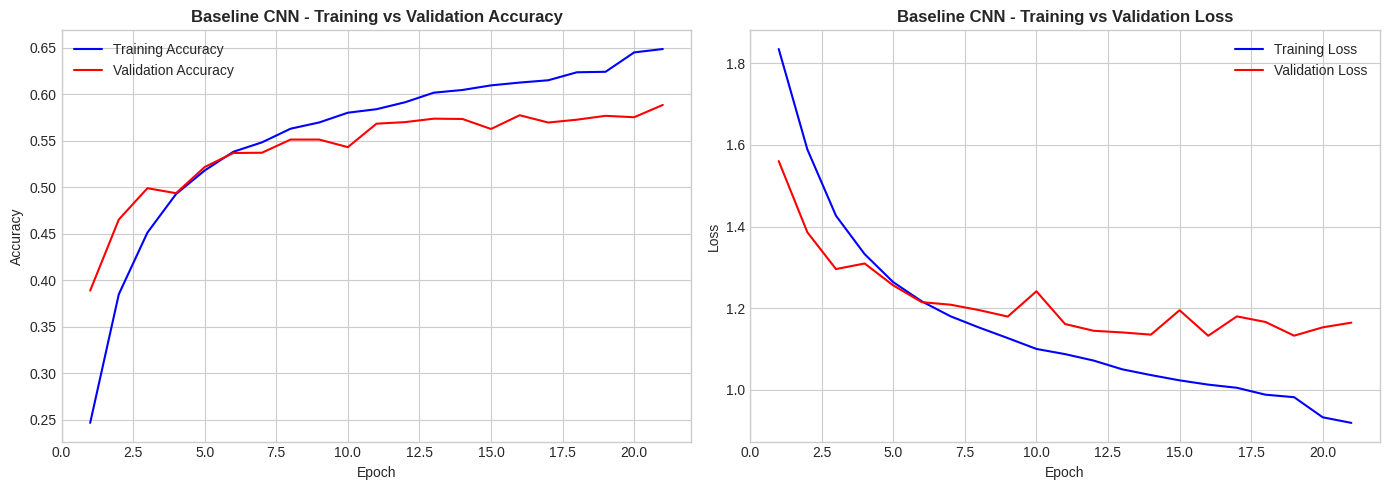

In [66]:
# Plot training vs validation accuracy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(baseline_history.history['accuracy']) + 1)

# Accuracy
axes[0].plot(epochs_range, baseline_history.history['accuracy'], 'b-', label='Training Accuracy')
axes[0].plot(epochs_range, baseline_history.history['val_accuracy'], 'r-', label='Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Baseline CNN - Training vs Validation Accuracy', fontweight='bold')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(epochs_range, baseline_history.history['loss'], 'b-', label='Training Loss')
axes[1].plot(epochs_range, baseline_history.history['val_loss'], 'r-', label='Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Baseline CNN - Training vs Validation Loss', fontweight='bold')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [67]:
# Print final training metrics
final_train_acc = baseline_history.history['accuracy'][-1]
final_val_acc = baseline_history.history['val_accuracy'][-1]
final_train_loss = baseline_history.history['loss'][-1]
final_val_loss = baseline_history.history['val_loss'][-1]
best_val_acc = max(baseline_history.history['val_accuracy'])
best_epoch = baseline_history.history['val_accuracy'].index(best_val_acc) + 1

print("Baseline Model - Final Training Metrics:")
print(f"  Final Training Accuracy:     {final_train_acc:.4f}")
print(f"  Final Validation Accuracy:   {final_val_acc:.4f}")
print(f"  Final Training Loss:         {final_train_loss:.4f}")
print(f"  Final Validation Loss:       {final_val_loss:.4f}")
print(f"  Best Validation Accuracy:    {best_val_acc:.4f} (Epoch {best_epoch})")
print(f"  Total Epochs Trained:        {len(baseline_history.history['accuracy'])}")
print(f"  Training Time:               {baseline_train_time:.1f}s")

Baseline Model - Final Training Metrics:
  Final Training Accuracy:     0.6486
  Final Validation Accuracy:   0.5885
  Final Training Loss:         0.9184
  Final Validation Loss:       1.1642
  Best Validation Accuracy:    0.5885 (Epoch 21)
  Total Epochs Trained:        21
  Training Time:               731.6s


### 3.6 Model Evaluation on Test Set


In [68]:
# Evaluate on test set
print("Evaluating baseline model on test set...")
baseline_test_loss, baseline_test_acc = baseline_model.evaluate(test_generator, verbose=1)

print(f"\nBaseline Model - Test Results:")
print(f"  Test Accuracy: {baseline_test_acc:.4f}")
print(f"  Test Loss:     {baseline_test_loss:.4f}")

Evaluating baseline model on test set...
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.4511 - loss: 1.6495

Baseline Model - Test Results:
  Test Accuracy: 0.5214
  Test Loss:     1.4186


In [69]:
# Generate predictions on test set
test_generator.reset()
baseline_predictions = baseline_model.predict(test_generator, verbose=1)
baseline_pred_classes = np.argmax(baseline_predictions, axis=1)
true_classes = test_generator.classes

print(f"Predictions generated: {len(baseline_pred_classes)} samples")

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
Predictions generated: 1680 samples


In [70]:
# Classification report
print("Baseline CNN - Classification Report:")
print("=" * 60)
print(classification_report(true_classes, baseline_pred_classes, target_names=classes))

Baseline CNN - Classification Report:
              precision    recall  f1-score   support

       angry       0.51      0.39      0.44       276
     disgust       0.75      0.30      0.42        81
        fear       0.56      0.25      0.35       270
       happy       0.62      0.82      0.71       287
     neutral       0.40      0.67      0.50       279
         sad       0.43      0.44      0.43       287
    surprise       0.71      0.65      0.68       200

    accuracy                           0.52      1680
   macro avg       0.57      0.50      0.50      1680
weighted avg       0.54      0.52      0.51      1680



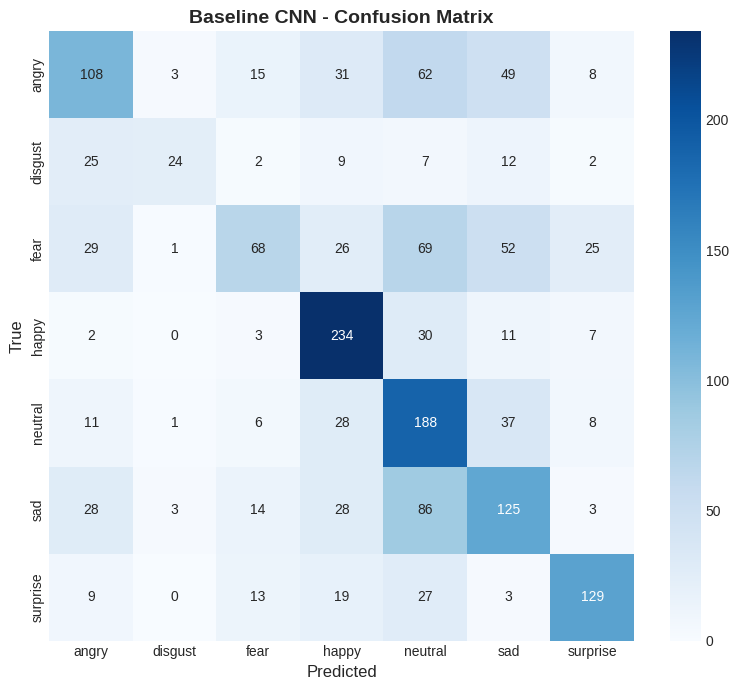

In [71]:
# Confusion matrix
cm = confusion_matrix(true_classes, baseline_pred_classes)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title('Baseline CNN - Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [72]:
# Per-class accuracy
print("Baseline CNN - Per-Class Accuracy:")
print("-" * 40)
for i, cls in enumerate(classes):
    cls_mask = true_classes == i
    cls_acc = np.mean(baseline_pred_classes[cls_mask] == i)
    print(f"  {cls:<10}: {cls_acc:.4f} ({np.sum(cls_mask)} samples)")

Baseline CNN - Per-Class Accuracy:
----------------------------------------
  angry     : 0.3913 (276 samples)
  disgust   : 0.2963 (81 samples)
  fear      : 0.2519 (270 samples)
  happy     : 0.8153 (287 samples)
  neutral   : 0.6738 (279 samples)
  sad       : 0.4355 (287 samples)
  surprise  : 0.6450 (200 samples)


### 3.7 Inference on Sample Images


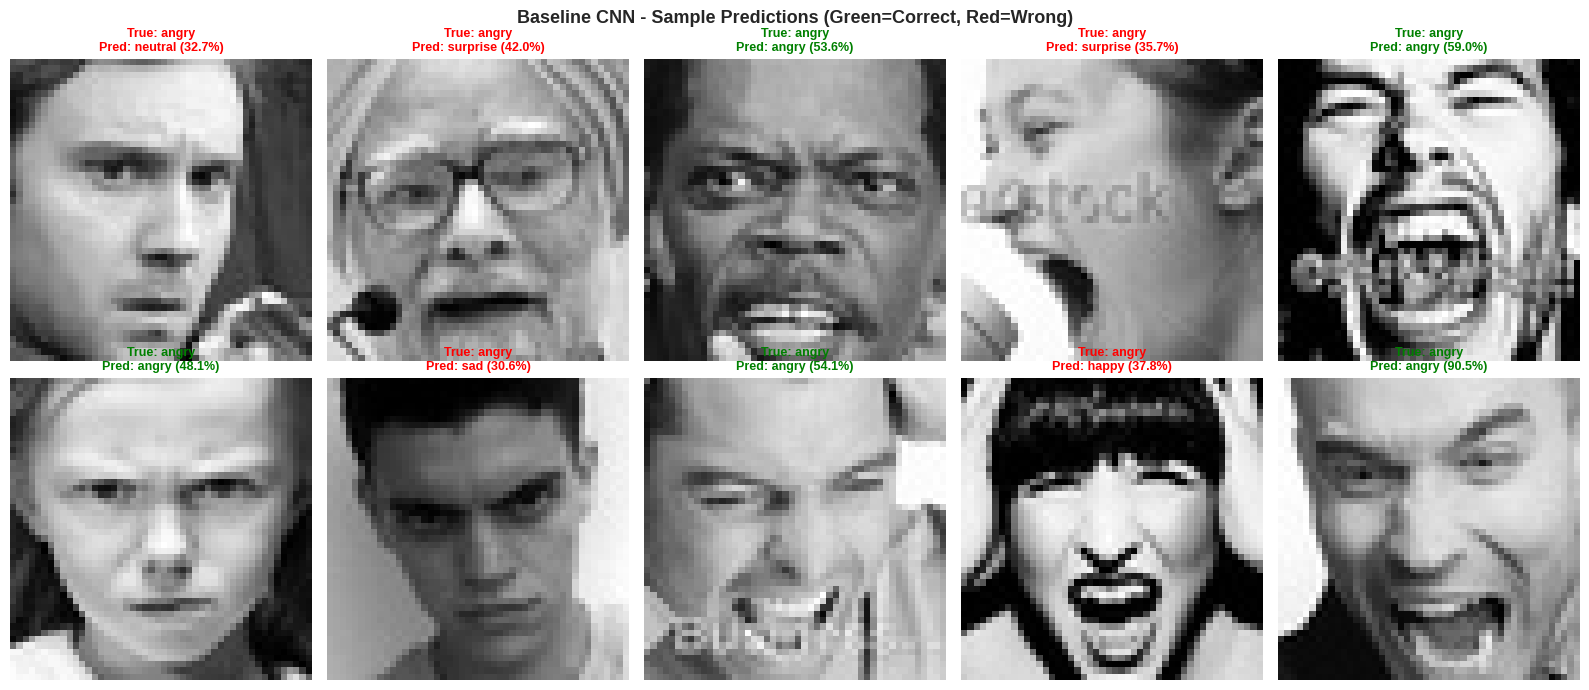

In [73]:
# Perform inference on sample test images and display results
fig, axes = plt.subplots(2, 5, figsize=(16, 7))

test_generator.reset()
test_batch, test_labels = next(iter(test_generator))

for i in range(10):
    row, col = i // 5, i % 5
    img = test_batch[i].reshape(48, 48)
    true_label = classes[np.argmax(test_labels[i])]
    
    pred_probs = baseline_model.predict(test_batch[i:i+1], verbose=0)
    pred_label = classes[np.argmax(pred_probs)]
    confidence = np.max(pred_probs) * 100
    
    axes[row, col].imshow(img, cmap='gray')
    color = 'green' if pred_label == true_label else 'red'
    axes[row, col].set_title(f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)", 
                              fontsize=9, color=color, fontweight='bold')
    axes[row, col].axis('off')

fig.suptitle('Baseline CNN - Sample Predictions (Green=Correct, Red=Wrong)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.8 Baseline Model Observations


## 4. Deeper Architecture with Regularization

This section extends the baseline model by:
- **Doubling the convolutional layers** (6 Conv layers instead of 3)
- **Increasing filter counts** (64→128→256 with two Conv layers per block)
- Adding **Batch Normalization** after each Conv layer
- Adding **Dropout** to prevent overfitting

### 4.1 Model Architecture

In [74]:
# Build deeper CNN with regularization
def build_deeper_cnn(input_shape=(48, 48, 1), num_classes=7):
    model = Sequential([
        # Conv Block 1 (2 Conv layers)
        Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        
        # Conv Block 2 (2 Conv layers)
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        
        # Conv Block 3 (2 Conv layers)
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        
        # Flatten
        Flatten(),
        
        # FC Layer 1
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        
        # FC Layer 2
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        
        # FC Layer 3
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        
        # Output Layer
        Dense(num_classes, activation='softmax')
    ])
    return model

deeper_model = build_deeper_cnn(INPUT_SHAPE, NUM_CLASSES)
print("Deeper CNN model built successfully.")

Deeper CNN model built successfully.


### 4.2 Model Summary

In [75]:
# Print deeper model summary
deeper_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 48, 48, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 48, 48, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │     4,719,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 6,035,655 (23.02 MB)

 Trainable params: 6,032,071 (23.01 MB)

 Non-trainable params: 3,584 (14.00 KB)

In [76]:
# Compare architecture: Baseline vs Deeper
print("=" * 65)
print("ARCHITECTURE COMPARISON: BASELINE vs DEEPER CNN")
print("=" * 65)
print(f"{'Feature':<30} {'Baseline':<15} {'Deeper':<15}")
print("-" * 65)
print(f"{'Conv Layers':<30} {'3':<15} {'6':<15}")
print(f"{'Filters':<30} {'32→64→128':<15} {'64→128→256':<15}")
print(f"{'BatchNormalization':<30} {'No':<15} {'Yes (9 layers)':<15}")
print(f"{'Dropout':<30} {'No':<15} {'Yes (0.25/0.5)':<15}")
print(f"{'FC Layers':<30} {'3':<15} {'3':<15}")
print(f"{'FC Neurons':<30} {'256→128→64':<15} {'512→256→128':<15}")
print(f"{'Total Parameters':<30} {baseline_model.count_params():,}{'':>5} {deeper_model.count_params():,}")
print("-" * 65)

ARCHITECTURE COMPARISON: BASELINE vs DEEPER CNN
Feature                        Baseline        Deeper         
-----------------------------------------------------------------
Conv Layers                    3               6              
Filters                        32→64→128       64→128→256     
BatchNormalization             No              Yes (9 layers) 
Dropout                        No              Yes (0.25/0.5) 
FC Layers                      3               3              
FC Neurons                     256→128→64      512→256→128    
Total Parameters               1,314,183      6,035,655
-----------------------------------------------------------------


### 4.3 Compile the Model

In [77]:
# Compile deeper model
deeper_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Deeper model compiled.")
print(f"  Optimizer:       Adam (lr=0.001)")
print(f"  Loss function:   Categorical Crossentropy")
print(f"  Metrics:         Accuracy")

Deeper model compiled.
  Optimizer:       Adam (lr=0.001)
  Loss function:   Categorical Crossentropy
  Metrics:         Accuracy


### 4.4 Train the Deeper Model

In [78]:
# Train deeper model with callbacks
EPOCHS_DEEP = 50

early_stopping_deep = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_deep = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

print(f"Training deeper model for up to {EPOCHS_DEEP} epochs...")
print(f"Using device: {DEVICE}")
print(f"  EarlyStopping: patience=5")
print(f"  ReduceLROnPlateau: factor=0.5, patience=3")
print()

start_time_deep = time.time()

deeper_history = deeper_model.fit(
    train_generator_aug,
    epochs=EPOCHS_DEEP,
    validation_data=val_generator,
    callbacks=[early_stopping_deep, reduce_lr_deep],
    class_weight=class_weights,
    verbose=1
)

deeper_train_time = time.time() - start_time_deep
print(f"\nTraining completed in {deeper_train_time:.1f} seconds ({deeper_train_time/60:.1f} minutes)")

Training deeper model for up to 50 epochs...
Using device: GPU
  EarlyStopping: patience=5
  ReduceLROnPlateau: factor=0.5, patience=3

Epoch 1/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 78s 74ms/step - accuracy: 0.1697 - loss: 2.5108 - val_accuracy: 0.2468 - val_loss: 1.8595 - learning_rate: 0.0010
Epoch 2/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 35s 48ms/step - accuracy: 0.2603 - loss: 1.8408 - val_accuracy: 0.2908 - val_loss: 1.7965 - learning_rate: 0.0010
Epoch 3/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 36s 49ms/step - accuracy: 0.3833 - loss: 1.5902 - val_accuracy: 0.4499 - val_loss: 1.4459 - learning_rate: 0.0010
Epoch 4/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 35s 48ms/step - accuracy: 0.4674 - loss: 1.3928 - val_accuracy: 0.4981 - val_loss: 1.3803 - learning_rate: 0.0010
Epoch 5/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 35s 48ms/step - accuracy: 0.5098 - loss: 1.2905 - val_accuracy: 0.5076 - val_loss: 1.3719 - learning_rate: 0.0010
Epoch 6/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 35s 48ms/step - accuracy: 0.5456 - loss: 1.2029 - val_

### 4.5 Training & Validation Curves

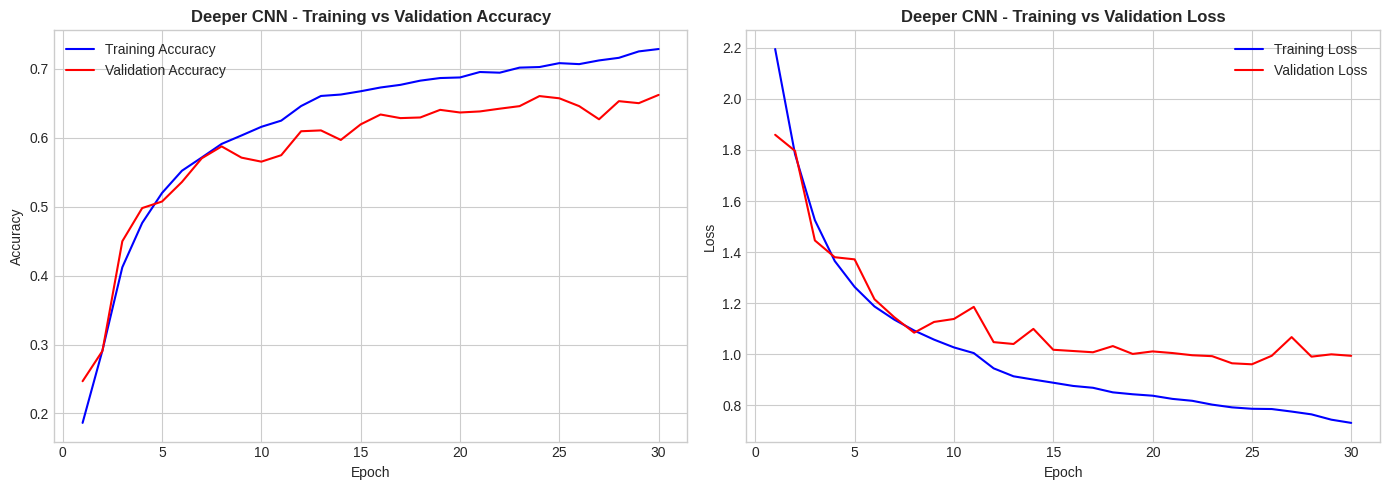

In [79]:
# Plot deeper model training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range_deep = range(1, len(deeper_history.history['accuracy']) + 1)

# Accuracy
axes[0].plot(epochs_range_deep, deeper_history.history['accuracy'], 'b-', label='Training Accuracy')
axes[0].plot(epochs_range_deep, deeper_history.history['val_accuracy'], 'r-', label='Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Deeper CNN - Training vs Validation Accuracy', fontweight='bold')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(epochs_range_deep, deeper_history.history['loss'], 'b-', label='Training Loss')
axes[1].plot(epochs_range_deep, deeper_history.history['val_loss'], 'r-', label='Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Deeper CNN - Training vs Validation Loss', fontweight='bold')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### 4.6 Compare Training Curves: Baseline vs Deeper

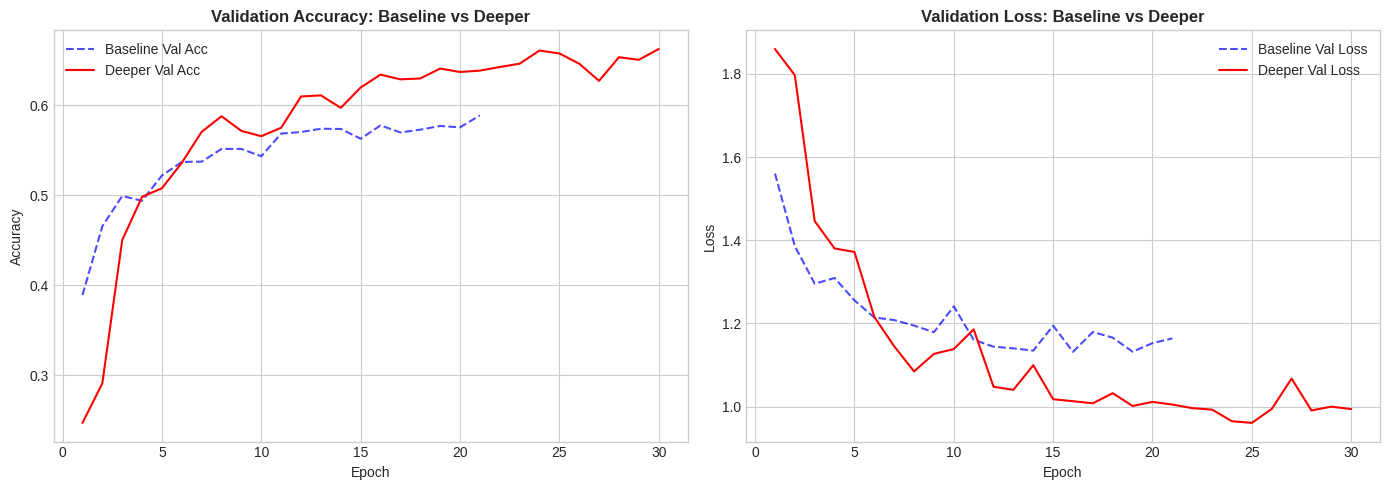

In [80]:
# Side-by-side training curve comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_base = range(1, len(baseline_history.history['accuracy']) + 1)
epochs_deep = range(1, len(deeper_history.history['accuracy']) + 1)

# Accuracy comparison
axes[0].plot(epochs_base, baseline_history.history['val_accuracy'], 'b--', label='Baseline Val Acc', alpha=0.7)
axes[0].plot(epochs_deep, deeper_history.history['val_accuracy'], 'r-', label='Deeper Val Acc')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Validation Accuracy: Baseline vs Deeper', fontweight='bold')
axes[0].legend()
axes[0].grid(True)

# Loss comparison
axes[1].plot(epochs_base, baseline_history.history['val_loss'], 'b--', label='Baseline Val Loss', alpha=0.7)
axes[1].plot(epochs_deep, deeper_history.history['val_loss'], 'r-', label='Deeper Val Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Validation Loss: Baseline vs Deeper', fontweight='bold')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [81]:
# Print training time comparison
print("Training Time Comparison:")
print(f"  Baseline: {baseline_train_time:.1f}s ({baseline_train_time/60:.1f} min)")
print(f"  Deeper:   {deeper_train_time:.1f}s ({deeper_train_time/60:.1f} min)")
print(f"  Difference: {deeper_train_time - baseline_train_time:.1f}s ({(deeper_train_time/baseline_train_time - 1)*100:.1f}% slower)")

Training Time Comparison:
  Baseline: 731.6s (12.2 min)
  Deeper:   1102.2s (18.4 min)
  Difference: 370.7s (50.7% slower)


### 4.7 Model Evaluation on Test Set

In [82]:
# Evaluate deeper model on test set
print("Evaluating deeper model on test set...")
test_generator.reset()
deeper_test_loss, deeper_test_acc = deeper_model.evaluate(test_generator, verbose=1)

print(f"\nDeeper Model - Test Results:")
print(f"  Test Accuracy: {deeper_test_acc:.4f}")
print(f"  Test Loss:     {deeper_test_loss:.4f}")

Evaluating deeper model on test set...
27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.5837 - loss: 1.2799

Deeper Model - Test Results:
  Test Accuracy: 0.5988
  Test Loss:     1.2022


In [83]:
# Generate predictions
test_generator.reset()
deeper_predictions = deeper_model.predict(test_generator, verbose=1)
deeper_pred_classes = np.argmax(deeper_predictions, axis=1)
true_classes = test_generator.classes

print(f"Predictions generated: {len(deeper_pred_classes)} samples")

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step
Predictions generated: 1680 samples


In [84]:
# Classification report
print("Deeper CNN - Classification Report:")
print("=" * 60)
print(classification_report(true_classes, deeper_pred_classes, target_names=classes))

Deeper CNN - Classification Report:
              precision    recall  f1-score   support

       angry       0.52      0.62      0.57       276
     disgust       0.90      0.35      0.50        81
        fear       0.55      0.34      0.42       270
       happy       0.73      0.88      0.80       287
     neutral       0.54      0.66      0.59       279
         sad       0.50      0.54      0.52       287
    surprise       0.79      0.63      0.70       200

    accuracy                           0.60      1680
   macro avg       0.65      0.57      0.58      1680
weighted avg       0.61      0.60      0.59      1680



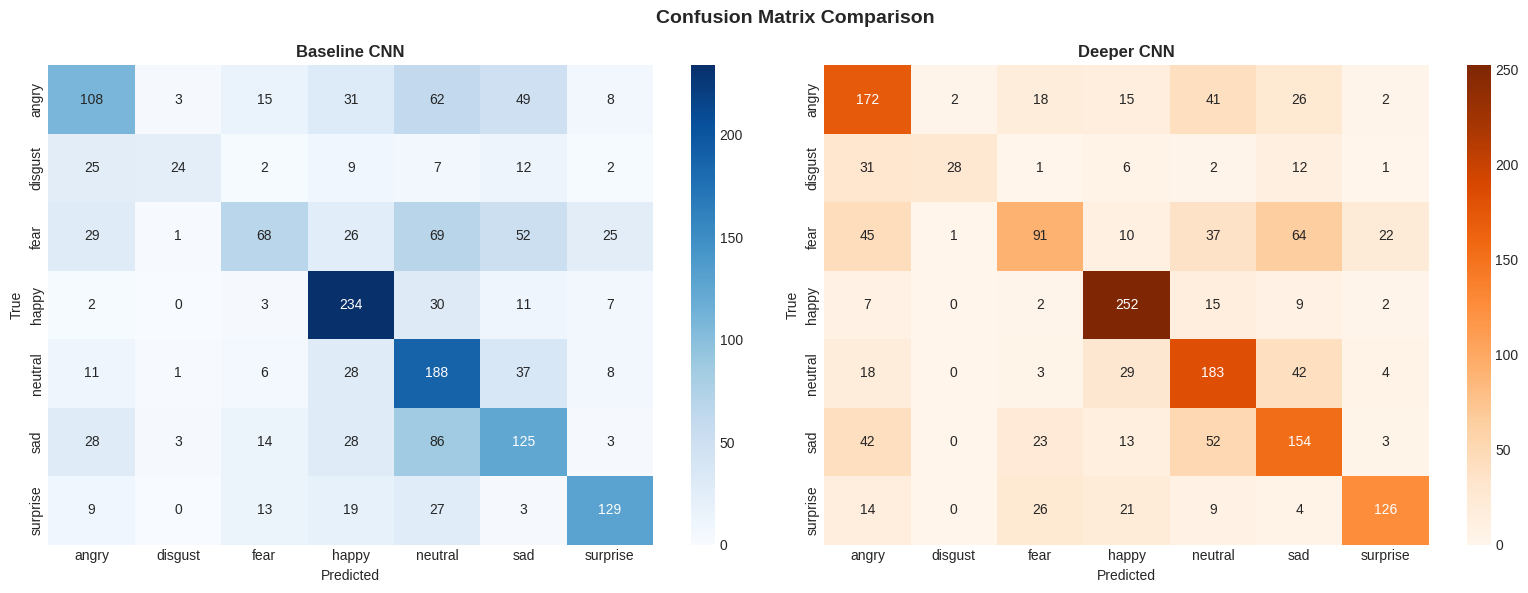

In [85]:
# Confusion matrix
cm_deep = confusion_matrix(true_classes, deeper_pred_classes)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Baseline confusion matrix
cm_base = confusion_matrix(true_classes, baseline_pred_classes)
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_title('Baseline CNN', fontweight='bold')

# Deeper confusion matrix
sns.heatmap(cm_deep, annot=True, fmt='d', cmap='Oranges', xticklabels=classes, yticklabels=classes, ax=axes[1])
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].set_title('Deeper CNN', fontweight='bold')

fig.suptitle('Confusion Matrix Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [86]:
# Per-class accuracy comparison
print("Per-Class Accuracy Comparison:")
print("-" * 55)
print(f"{'Class':<12} {'Baseline':<12} {'Deeper':<12} {'Change':<12}")
print("-" * 55)
for i, cls in enumerate(classes):
    cls_mask = true_classes == i
    base_acc = np.mean(baseline_pred_classes[cls_mask] == i)
    deep_acc = np.mean(deeper_pred_classes[cls_mask] == i)
    change = deep_acc - base_acc
    arrow = '↑' if change > 0 else '↓' if change < 0 else '='
    print(f"  {cls:<10} {base_acc:.4f}       {deep_acc:.4f}       {arrow} {abs(change):.4f}")
print("-" * 55)
print(f"  {'OVERALL':<10} {baseline_test_acc:.4f}       {deeper_test_acc:.4f}       {'↑' if deeper_test_acc > baseline_test_acc else '↓'} {abs(deeper_test_acc - baseline_test_acc):.4f}")

Per-Class Accuracy Comparison:
-------------------------------------------------------
Class        Baseline     Deeper       Change      
-------------------------------------------------------
  angry      0.3913       0.6232       ↑ 0.2319
  disgust    0.2963       0.3457       ↑ 0.0494
  fear       0.2519       0.3370       ↑ 0.0852
  happy      0.8153       0.8780       ↑ 0.0627
  neutral    0.6738       0.6559       ↓ 0.0179
  sad        0.4355       0.5366       ↑ 0.1010
  surprise   0.6450       0.6300       ↓ 0.0150
-------------------------------------------------------
  OVERALL    0.5214       0.5988       ↑ 0.0774


### 4.8 Inference on Sample Images

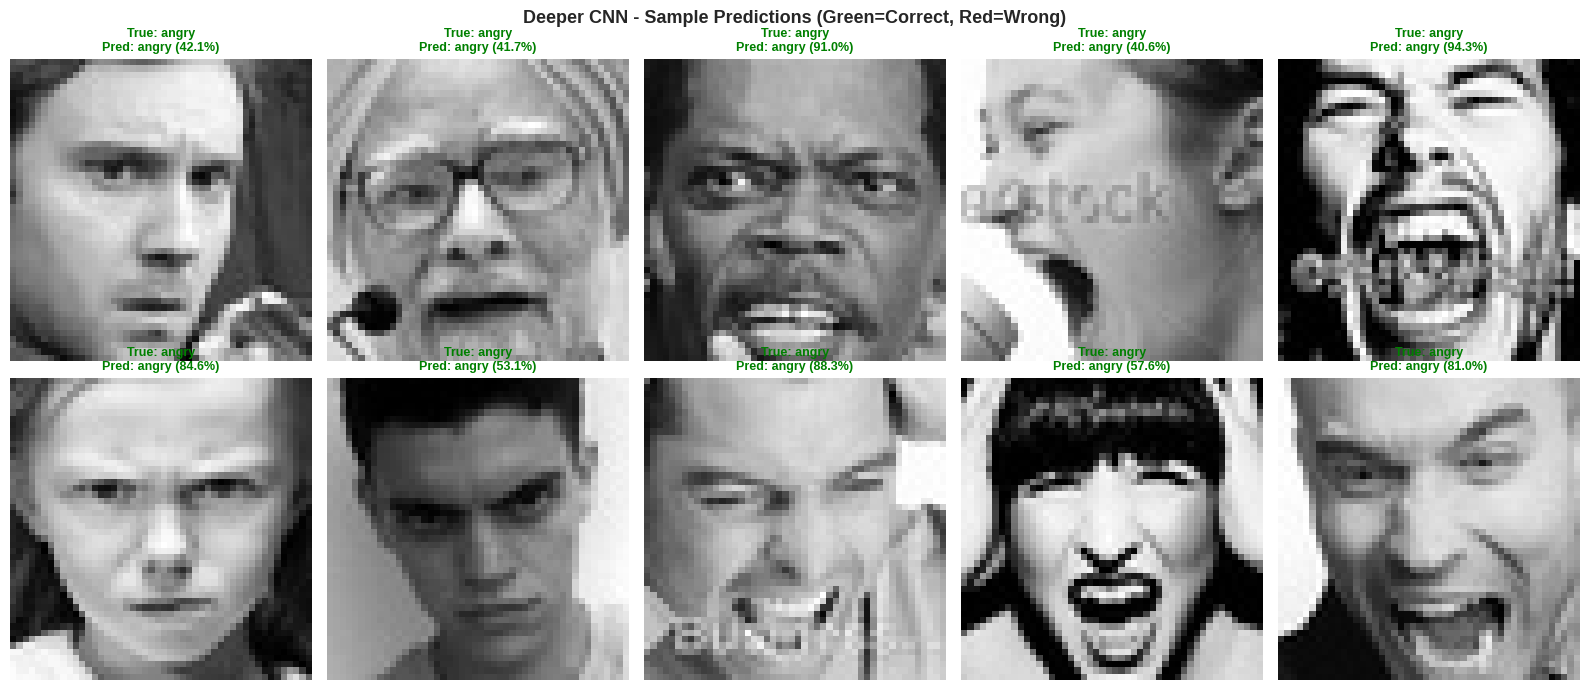

In [87]:
# Inference on sample test images
fig, axes = plt.subplots(2, 5, figsize=(16, 7))

test_generator.reset()
test_batch, test_labels = next(iter(test_generator))

for i in range(10):
    row, col = i // 5, i % 5
    img = test_batch[i].reshape(48, 48)
    true_label = classes[np.argmax(test_labels[i])]
    
    pred_probs = deeper_model.predict(test_batch[i:i+1], verbose=0)
    pred_label = classes[np.argmax(pred_probs)]
    confidence = np.max(pred_probs) * 100
    
    axes[row, col].imshow(img, cmap='gray')
    color = 'green' if pred_label == true_label else 'red'
    axes[row, col].set_title(f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)", 
                              fontsize=9, color=color, fontweight='bold')
    axes[row, col].axis('off')

fig.suptitle('Deeper CNN - Sample Predictions (Green=Correct, Red=Wrong)', 
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 4.9 Deeper Model Observations

**Key comparisons with baseline:**
- Impact of BatchNormalization and Dropout on overfitting
- Effect of doubling filters and layers on accuracy
- Training time trade-off vs performance gain
- Per-class improvements (especially for underrepresented classes)

## 5. Experimentation and Comparative Analysis

This section covers:
1. **Baseline vs Deeper Model Performance** comparison
2. **Computational Efficiency** analysis
3. **Optimizer Analysis**: SGD vs Adam
4. **Ablation Study**: removing Dropout and BatchNormalization
5. **Challenges and Observations**

### 5.1 Baseline vs Deeper Model Performance

In [88]:
# Comprehensive comparison table
from sklearn.metrics import precision_score, recall_score, f1_score

# Compute metrics for both models
base_precision = precision_score(true_classes, baseline_pred_classes, average='weighted')
base_recall = recall_score(true_classes, baseline_pred_classes, average='weighted')
base_f1 = f1_score(true_classes, baseline_pred_classes, average='weighted')

deep_precision = precision_score(true_classes, deeper_pred_classes, average='weighted')
deep_recall = recall_score(true_classes, deeper_pred_classes, average='weighted')
deep_f1 = f1_score(true_classes, deeper_pred_classes, average='weighted')

print("=" * 60)
print("BASELINE vs DEEPER MODEL - FULL COMPARISON")
print("=" * 60)
print(f"{'Metric':<25} {'Baseline':<15} {'Deeper':<15}")
print("-" * 60)
print(f"{'Test Accuracy':<25} {baseline_test_acc:.4f}         {deeper_test_acc:.4f}")
print(f"{'Test Loss':<25} {baseline_test_loss:.4f}         {deeper_test_loss:.4f}")
print(f"{'Precision (weighted)':<25} {base_precision:.4f}         {deep_precision:.4f}")
print(f"{'Recall (weighted)':<25} {base_recall:.4f}         {deep_recall:.4f}")
print(f"{'F1-Score (weighted)':<25} {base_f1:.4f}         {deep_f1:.4f}")
print(f"{'Training Time':<25} {baseline_train_time:.1f}s          {deeper_train_time:.1f}s")
print(f"{'Parameters':<25} {baseline_model.count_params():,}       {deeper_model.count_params():,}")
print(f"{'Epochs Trained':<25} {len(baseline_history.history["accuracy"])}              {len(deeper_history.history["accuracy"])}")
print("-" * 60)

BASELINE vs DEEPER MODEL - FULL COMPARISON
Metric                    Baseline        Deeper         
------------------------------------------------------------
Test Accuracy             0.5214         0.5988
Test Loss                 1.4186         1.2022
Precision (weighted)      0.5416         0.6110
Recall (weighted)         0.5214         0.5988
F1-Score (weighted)       0.5079         0.5906
Training Time             731.6s          1102.2s
Parameters                1,314,183       6,035,655
Epochs Trained            21              30
------------------------------------------------------------


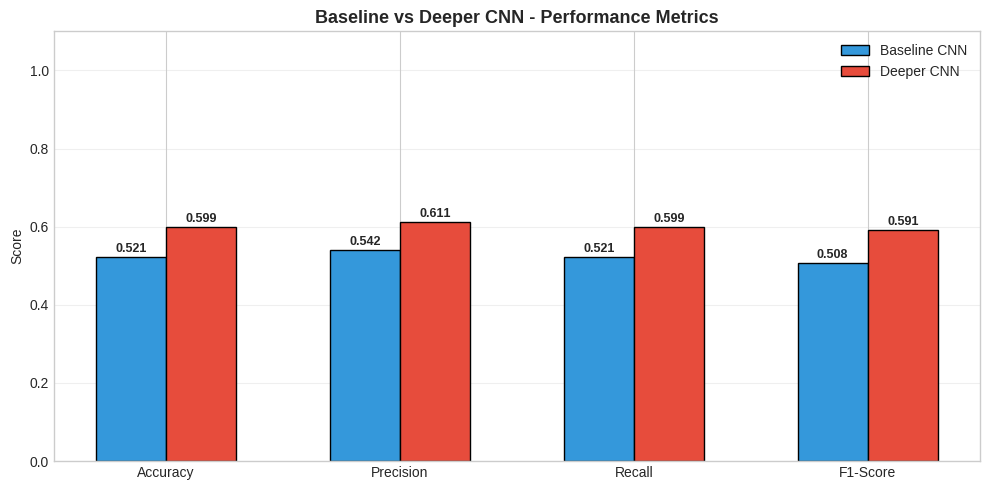

In [89]:
# Bar chart comparison of all metrics
fig, ax = plt.subplots(figsize=(10, 5))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
baseline_vals = [baseline_test_acc, base_precision, base_recall, base_f1]
deeper_vals = [deeper_test_acc, deep_precision, deep_recall, deep_f1]

x = np.arange(len(metrics))
width = 0.3

bars1 = ax.bar(x - width/2, baseline_vals, width, label='Baseline CNN', color='#3498db', edgecolor='black')
bars2 = ax.bar(x + width/2, deeper_vals, width, label='Deeper CNN', color='#e74c3c', edgecolor='black')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005, 
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005, 
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylabel('Score')
ax.set_title('Baseline vs Deeper CNN - Performance Metrics', fontweight='bold', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 5.2 Computational Efficiency

In [90]:
# Computational cost comparison
print("=" * 60)
print("COMPUTATIONAL EFFICIENCY COMPARISON")
print("=" * 60)
print(f"{'Metric':<30} {'Baseline':<15} {'Deeper':<15}")
print("-" * 60)
print(f"{'Total Parameters':<30} {baseline_model.count_params():,}     {deeper_model.count_params():,}")
print(f"{'Training Time':<30} {baseline_train_time:.1f}s          {deeper_train_time:.1f}s")
print(f"{'Time per Epoch':<30} {baseline_train_time/len(baseline_history.history['accuracy']):.1f}s          {deeper_train_time/len(deeper_history.history['accuracy']):.1f}s")
print(f"{'Epochs Trained':<30} {len(baseline_history.history['accuracy'])}              {len(deeper_history.history['accuracy'])}")
print(f"{'Accuracy Gain':<30} {'—':<15} {(deeper_test_acc - baseline_test_acc)*100:+.2f}%")
print("-" * 60)

param_increase = (deeper_model.count_params() / baseline_model.count_params() - 1) * 100
time_increase = (deeper_train_time / baseline_train_time - 1) * 100
acc_increase = (deeper_test_acc - baseline_test_acc) * 100

print(f"\nThe deeper model has {param_increase:.0f}% more parameters")
print(f"and took {time_increase:.0f}% longer to train")
print(f"for a {acc_increase:+.2f}% change in accuracy.")

COMPUTATIONAL EFFICIENCY COMPARISON
Metric                         Baseline        Deeper         
------------------------------------------------------------
Total Parameters               1,314,183     6,035,655
Training Time                  731.6s          1102.2s
Time per Epoch                 34.8s          36.7s
Epochs Trained                 21              30
Accuracy Gain                  —               +7.74%
------------------------------------------------------------

The deeper model has 359% more parameters
and took 51% longer to train
for a +7.74% change in accuracy.


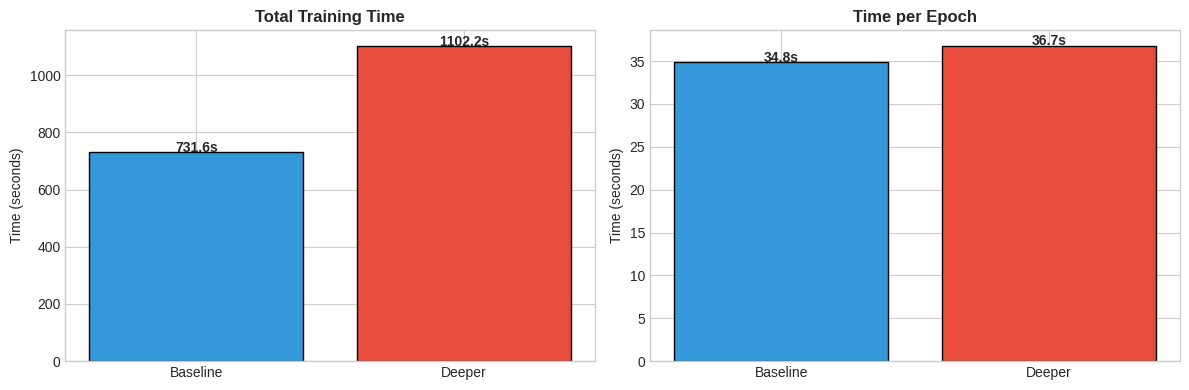

In [91]:
# Training time visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart - total time
models = ['Baseline', 'Deeper']
times = [baseline_train_time, deeper_train_time]
colors_bar = ['#3498db', '#e74c3c']
axes[0].bar(models, times, color=colors_bar, edgecolor='black')
for i, t in enumerate(times):
    axes[0].text(i, t + 1, f'{t:.1f}s', ha='center', fontweight='bold')
axes[0].set_ylabel('Time (seconds)')
axes[0].set_title('Total Training Time', fontweight='bold')

# Bar chart - time per epoch
time_per_epoch = [
    baseline_train_time / len(baseline_history.history['accuracy']),
    deeper_train_time / len(deeper_history.history['accuracy'])
]
axes[1].bar(models, time_per_epoch, color=colors_bar, edgecolor='black')
for i, t in enumerate(time_per_epoch):
    axes[1].text(i, t + 0.1, f'{t:.1f}s', ha='center', fontweight='bold')
axes[1].set_ylabel('Time (seconds)')
axes[1].set_title('Time per Epoch', fontweight='bold')

plt.tight_layout()
plt.show()

### 5.3 Optimizer Analysis: SGD vs Adam

In [92]:
# Build fresh deeper model for SGD training
deeper_sgd_model = build_deeper_cnn(INPUT_SHAPE, NUM_CLASSES)

deeper_sgd_model.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Deeper model (SGD) compiled.")
print(f"  Optimizer: SGD (lr=0.01, momentum=0.9)")

Deeper model (SGD) compiled.
  Optimizer: SGD (lr=0.01, momentum=0.9)


In [93]:
# Train with SGD
early_stopping_sgd = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_sgd = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

print("Training deeper model with SGD optimizer...")
print()

start_time_sgd = time.time()

sgd_history = deeper_sgd_model.fit(
    train_generator_aug,
    epochs=50,
    validation_data=val_generator,
    callbacks=[early_stopping_sgd, reduce_lr_sgd],
    class_weight=class_weights,
    verbose=1
)

sgd_train_time = time.time() - start_time_sgd
print(f"\nSGD training completed in {sgd_train_time:.1f} seconds ({sgd_train_time/60:.1f} minutes)")

Training deeper model with SGD optimizer...

Epoch 1/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 58s 61ms/step - accuracy: 0.1742 - loss: 2.2219 - val_accuracy: 0.2416 - val_loss: 1.8661 - learning_rate: 0.0100
Epoch 2/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 35s 47ms/step - accuracy: 0.1968 - loss: 1.9499 - val_accuracy: 0.2165 - val_loss: 1.8795 - learning_rate: 0.0100
Epoch 3/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 35s 47ms/step - accuracy: 0.2332 - loss: 1.8940 - val_accuracy: 0.2851 - val_loss: 1.8105 - learning_rate: 0.0100
Epoch 4/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 35s 47ms/step - accuracy: 0.2762 - loss: 1.8255 - val_accuracy: 0.3640 - val_loss: 1.6111 - learning_rate: 0.0100
Epoch 5/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 35s 47ms/step - accuracy: 0.3205 - loss: 1.7390 - val_accuracy: 0.3875 - val_loss: 1.5472 - learning_rate: 0.0100
Epoch 6/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 35s 48ms/step - accuracy: 0.3490 - loss: 1.6606 - val_accuracy: 0.4067 - val_loss: 1.5165 - learning_rate: 0.0100
Epoch 7/50
739/739 ━━━━━━━━━━━━

In [94]:
# Evaluate SGD model
test_generator.reset()
sgd_test_loss, sgd_test_acc = deeper_sgd_model.evaluate(test_generator, verbose=1)
print(f"\nSGD Model - Test Accuracy: {sgd_test_acc:.4f}, Test Loss: {sgd_test_loss:.4f}")

27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.5587 - loss: 1.2713

SGD Model - Test Accuracy: 0.5804, Test Loss: 1.1858


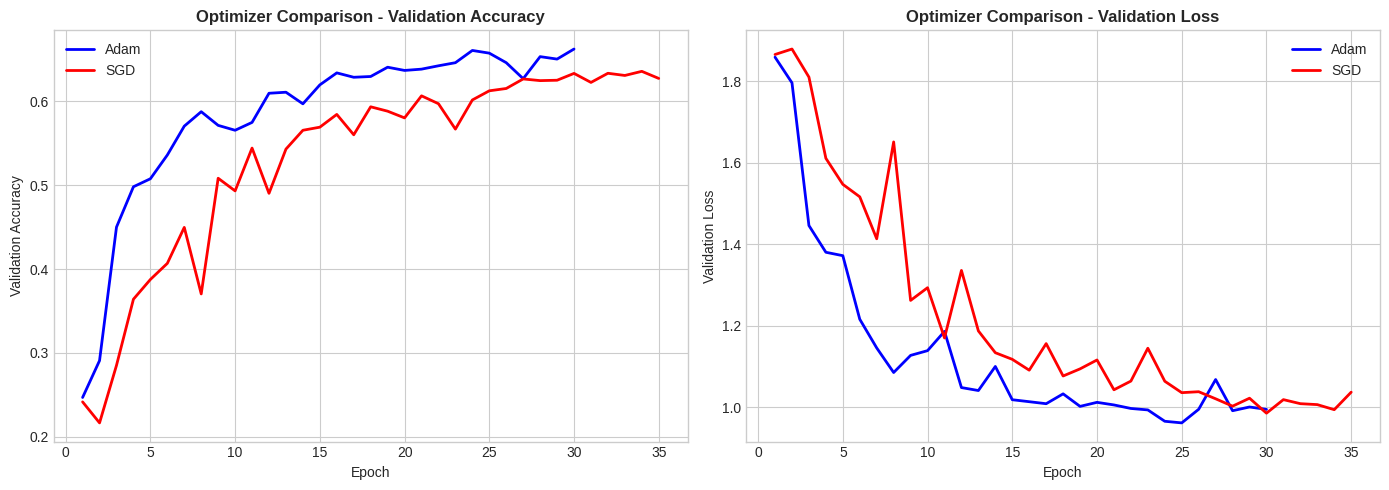

In [95]:
# Compare Adam vs SGD convergence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_adam = range(1, len(deeper_history.history['accuracy']) + 1)
epochs_sgd = range(1, len(sgd_history.history['accuracy']) + 1)

# Accuracy
axes[0].plot(epochs_adam, deeper_history.history['val_accuracy'], 'b-', label='Adam', linewidth=2)
axes[0].plot(epochs_sgd, sgd_history.history['val_accuracy'], 'r-', label='SGD', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Accuracy')
axes[0].set_title('Optimizer Comparison - Validation Accuracy', fontweight='bold')
axes[0].legend()
axes[0].grid(True)

# Loss
axes[1].plot(epochs_adam, deeper_history.history['val_loss'], 'b-', label='Adam', linewidth=2)
axes[1].plot(epochs_sgd, sgd_history.history['val_loss'], 'r-', label='SGD', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Loss')
axes[1].set_title('Optimizer Comparison - Validation Loss', fontweight='bold')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [96]:
# Optimizer comparison summary
print("=" * 60)
print("OPTIMIZER COMPARISON: ADAM vs SGD")
print("=" * 60)
print(f"{'Metric':<25} {'Adam':<15} {'SGD':<15}")
print("-" * 60)
print(f"{'Test Accuracy':<25} {deeper_test_acc:.4f}         {sgd_test_acc:.4f}")
print(f"{'Test Loss':<25} {deeper_test_loss:.4f}         {sgd_test_loss:.4f}")
print(f"{'Training Time':<25} {deeper_train_time:.1f}s          {sgd_train_time:.1f}s")
print(f"{'Epochs Trained':<25} {len(deeper_history.history['accuracy'])}              {len(sgd_history.history['accuracy'])}")
print(f"{'Best Val Accuracy':<25} {max(deeper_history.history['val_accuracy']):.4f}         {max(sgd_history.history['val_accuracy']):.4f}")
print("-" * 60)

winner = 'Adam' if deeper_test_acc > sgd_test_acc else 'SGD'
print(f"\nBetter optimizer for this task: {winner}")

OPTIMIZER COMPARISON: ADAM vs SGD
Metric                    Adam            SGD            
------------------------------------------------------------
Test Accuracy             0.5988         0.5804
Test Loss                 1.2022         1.1858
Training Time             1102.2s          1251.0s
Epochs Trained            30              35
Best Val Accuracy         0.6623         0.6357
------------------------------------------------------------

Better optimizer for this task: Adam


### 5.4 Ablation Study

The ablation study removes one regularization component at a time to measure its individual contribution:
1. **Without Dropout** — keep BatchNorm, remove all Dropout layers
2. **Without BatchNormalization** — keep Dropout, remove all BatchNorm layers

In [97]:
# Ablation 1: Deeper model WITHOUT Dropout
def build_deeper_no_dropout(input_shape=(48, 48, 1), num_classes=7):
    model = Sequential([
        Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        
        Flatten(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dense(num_classes, activation='softmax')
    ])
    return model

ablation_no_dropout = build_deeper_no_dropout(INPUT_SHAPE, NUM_CLASSES)
ablation_no_dropout.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
print(f"Ablation model (No Dropout) built: {ablation_no_dropout.count_params():,} params")

Ablation model (No Dropout) built: 6,035,655 params


In [98]:
# Train without Dropout
print("Training ablation model: No Dropout...")
es_abl1 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
lr_abl1 = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

start_abl1 = time.time()
abl1_history = ablation_no_dropout.fit(
    train_generator_aug, epochs=50, validation_data=val_generator,
    callbacks=[es_abl1, lr_abl1], class_weight=class_weights, verbose=1
)
abl1_time = time.time() - start_abl1

test_generator.reset()
abl1_loss, abl1_acc = ablation_no_dropout.evaluate(test_generator, verbose=0)
print(f"\nNo Dropout - Test Accuracy: {abl1_acc:.4f}, Time: {abl1_time:.1f}s")

Training ablation model: No Dropout...
Epoch 1/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 55s 58ms/step - accuracy: 0.2471 - loss: 1.9625 - val_accuracy: 0.3328 - val_loss: 1.8215 - learning_rate: 0.0010
Epoch 2/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 35s 47ms/step - accuracy: 0.4572 - loss: 1.4171 - val_accuracy: 0.5142 - val_loss: 1.2944 - learning_rate: 0.0010
Epoch 3/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 35s 47ms/step - accuracy: 0.5468 - loss: 1.2011 - val_accuracy: 0.5402 - val_loss: 1.2507 - learning_rate: 0.0010
Epoch 4/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 35s 47ms/step - accuracy: 0.5926 - loss: 1.0813 - val_accuracy: 0.5550 - val_loss: 1.1948 - learning_rate: 0.0010
Epoch 5/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 35s 47ms/step - accuracy: 0.6201 - loss: 0.9960 - val_accuracy: 0.5511 - val_loss: 1.2198 - learning_rate: 0.0010
Epoch 6/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 35s 47ms/step - accuracy: 0.6372 - loss: 0.9496 - val_accuracy: 0.5928 - val_loss: 1.1043 - learning_rate: 0.0010
Epoch 7/50
739/739 ━━━━━━━━━━━━━━━━━━

In [99]:
# Ablation 2: Deeper model WITHOUT BatchNormalization
def build_deeper_no_batchnorm(input_shape=(48, 48, 1), num_classes=7):
    model = Sequential([
        Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),
        
        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    return model

ablation_no_bn = build_deeper_no_batchnorm(INPUT_SHAPE, NUM_CLASSES)
ablation_no_bn.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
print(f"Ablation model (No BatchNorm) built: {ablation_no_bn.count_params():,} params")

Ablation model (No BatchNorm) built: 6,028,487 params


In [100]:
# Train without BatchNormalization
print("Training ablation model: No BatchNormalization...")
es_abl2 = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
lr_abl2 = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

start_abl2 = time.time()
abl2_history = ablation_no_bn.fit(
    train_generator_aug, epochs=50, validation_data=val_generator,
    callbacks=[es_abl2, lr_abl2], class_weight=class_weights, verbose=1
)
abl2_time = time.time() - start_abl2

test_generator.reset()
abl2_loss, abl2_acc = ablation_no_bn.evaluate(test_generator, verbose=0)
print(f"\nNo BatchNorm - Test Accuracy: {abl2_acc:.4f}, Time: {abl2_time:.1f}s")

Training ablation model: No BatchNormalization...
Epoch 1/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 51s 56ms/step - accuracy: 0.1443 - loss: 1.9477 - val_accuracy: 0.1410 - val_loss: 1.9483 - learning_rate: 0.0010
Epoch 2/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 35s 47ms/step - accuracy: 0.1418 - loss: 1.9462 - val_accuracy: 0.0897 - val_loss: 1.9495 - learning_rate: 0.0010
Epoch 3/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 35s 47ms/step - accuracy: 0.1413 - loss: 1.9461 - val_accuracy: 0.0131 - val_loss: 1.9464 - learning_rate: 0.0010
Epoch 4/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 35s 47ms/step - accuracy: 0.1444 - loss: 1.9460 - val_accuracy: 0.0897 - val_loss: 1.9493 - learning_rate: 0.0010
Epoch 5/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 35s 47ms/step - accuracy: 0.1392 - loss: 1.9461 - val_accuracy: 0.0897 - val_loss: 1.9481 - learning_rate: 0.0010
Epoch 6/50
739/739 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.1418 - loss: 1.9460
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
739/739 ━━━━━━━━━

### 5.4.1 Ablation Study Results

In [101]:
# Ablation study results table
print("=" * 70)
print("ABLATION STUDY RESULTS")
print("=" * 70)
print(f"{'Model Variant':<30} {'Test Acc':<12} {'Test Loss':<12} {'Time':<10}")
print("-" * 70)
print(f"{'Deeper (Full: BN + Dropout)':<30} {deeper_test_acc:.4f}       {deeper_test_loss:.4f}       {deeper_train_time:.1f}s")
print(f"{'Without Dropout':<30} {abl1_acc:.4f}       {abl1_loss:.4f}       {abl1_time:.1f}s")
print(f"{'Without BatchNormalization':<30} {abl2_acc:.4f}       {abl2_loss:.4f}       {abl2_time:.1f}s")
print("-" * 70)

# Impact analysis
dropout_impact = deeper_test_acc - abl1_acc
bn_impact = deeper_test_acc - abl2_acc
print(f"\nDropout contribution:           {dropout_impact:+.4f} accuracy")
print(f"BatchNormalization contribution: {bn_impact:+.4f} accuracy")
more_important = 'Dropout' if abs(dropout_impact) > abs(bn_impact) else 'BatchNormalization'
print(f"\nMore impactful regularization: {more_important}")

ABLATION STUDY RESULTS
Model Variant                  Test Acc     Test Loss    Time      
----------------------------------------------------------------------
Deeper (Full: BN + Dropout)    0.5988       1.2022       1102.2s
Without Dropout                0.6036       1.2306       714.4s
Without BatchNormalization     0.1708       1.9453       505.2s
----------------------------------------------------------------------

Dropout contribution:           -0.0048 accuracy
BatchNormalization contribution: +0.4280 accuracy

More impactful regularization: BatchNormalization


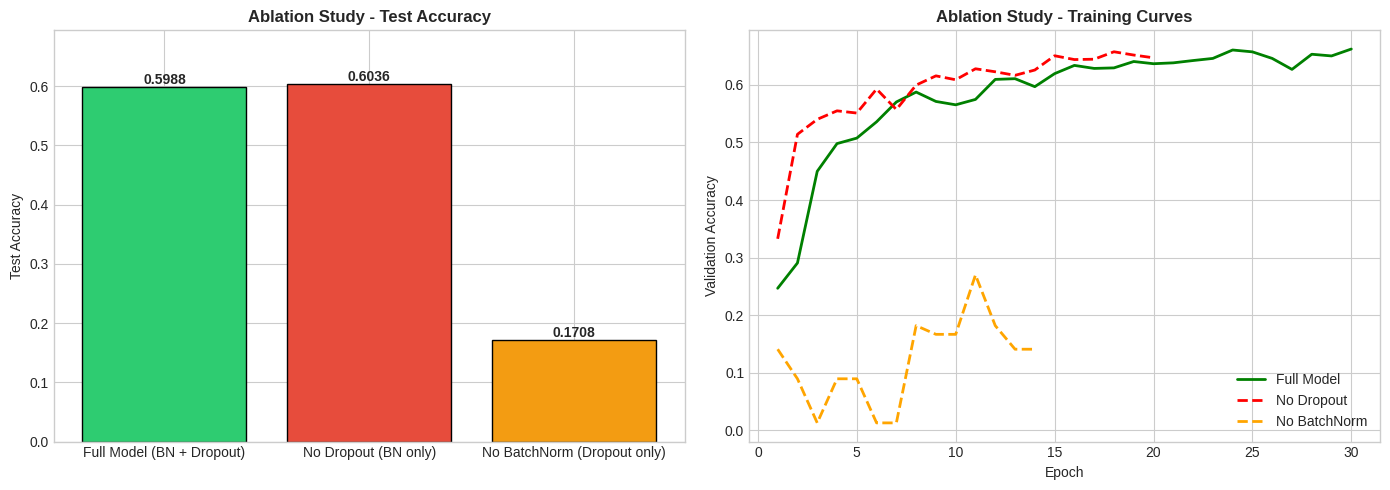

In [102]:
# Ablation visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy comparison
models_abl = ['Full Model (BN + Dropout)', 'No Dropout (BN only)', 'No BatchNorm (Dropout only)']
accs_abl = [deeper_test_acc, abl1_acc, abl2_acc]
colors_abl = ['#2ecc71', '#e74c3c', '#f39c12']

bars = axes[0].bar(models_abl, accs_abl, color=colors_abl, edgecolor='black')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005, 
                 f'{bar.get_height():.4f}', ha='center', fontweight='bold')
axes[0].set_ylabel('Test Accuracy')
axes[0].set_title('Ablation Study - Test Accuracy', fontweight='bold')
axes[0].set_ylim(0, max(accs_abl) * 1.15)

# Training curves comparison
ep_full = range(1, len(deeper_history.history['val_accuracy']) + 1)
ep_abl1 = range(1, len(abl1_history.history['val_accuracy']) + 1)
ep_abl2 = range(1, len(abl2_history.history['val_accuracy']) + 1)

axes[1].plot(ep_full, deeper_history.history['val_accuracy'], 'g-', label='Full Model', linewidth=2)
axes[1].plot(ep_abl1, abl1_history.history['val_accuracy'], 'r--', label='No Dropout', linewidth=2)
axes[1].plot(ep_abl2, abl2_history.history['val_accuracy'], color='orange', linestyle='--', label='No BatchNorm', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Ablation Study - Training Curves', fontweight='bold')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

### 5.5 Challenges and Observations

In [103]:
# Summary of all Part A models
print("=" * 75)
print("PART A - COMPLETE MODEL COMPARISON SUMMARY")
print("=" * 75)
print(f"{'Model':<30} {'Accuracy':<12} {'Loss':<12} {'Params':<15} {'Time':<10}")
print("-" * 75)
print(f"{'Baseline CNN':<30} {baseline_test_acc:.4f}       {baseline_test_loss:.4f}       {baseline_model.count_params():,}     {baseline_train_time:.1f}s")
print(f"{'Deeper CNN (Adam)':<30} {deeper_test_acc:.4f}       {deeper_test_loss:.4f}       {deeper_model.count_params():,}   {deeper_train_time:.1f}s")
print(f"{'Deeper CNN (SGD)':<30} {sgd_test_acc:.4f}       {sgd_test_loss:.4f}       {deeper_sgd_model.count_params():,}   {sgd_train_time:.1f}s")
print(f"{'Ablation: No Dropout':<30} {abl1_acc:.4f}       {abl1_loss:.4f}       {ablation_no_dropout.count_params():,}   {abl1_time:.1f}s")
print(f"{'Ablation: No BatchNorm':<30} {abl2_acc:.4f}       {abl2_loss:.4f}       {ablation_no_bn.count_params():,}   {abl2_time:.1f}s")
print("-" * 75)

best_acc = max(baseline_test_acc, deeper_test_acc, sgd_test_acc, abl1_acc, abl2_acc)
best_model_name = ['Baseline', 'Deeper(Adam)', 'Deeper(SGD)', 'No Dropout', 'No BatchNorm'][
    [baseline_test_acc, deeper_test_acc, sgd_test_acc, abl1_acc, abl2_acc].index(best_acc)]
print(f"\nBest performing model in Part A: {best_model_name} ({best_acc:.4f})")

PART A - COMPLETE MODEL COMPARISON SUMMARY
Model                          Accuracy     Loss         Params          Time      
---------------------------------------------------------------------------
Baseline CNN                   0.5214       1.4186       1,314,183     731.6s
Deeper CNN (Adam)              0.5988       1.2022       6,035,655   1102.2s
Deeper CNN (SGD)               0.5804       1.1858       6,035,655   1251.0s
Ablation: No Dropout           0.6036       1.2306       6,035,655   714.4s
Ablation: No BatchNorm         0.1708       1.9453       6,028,487   505.2s
---------------------------------------------------------------------------

Best performing model in Part A: No Dropout (0.6036)


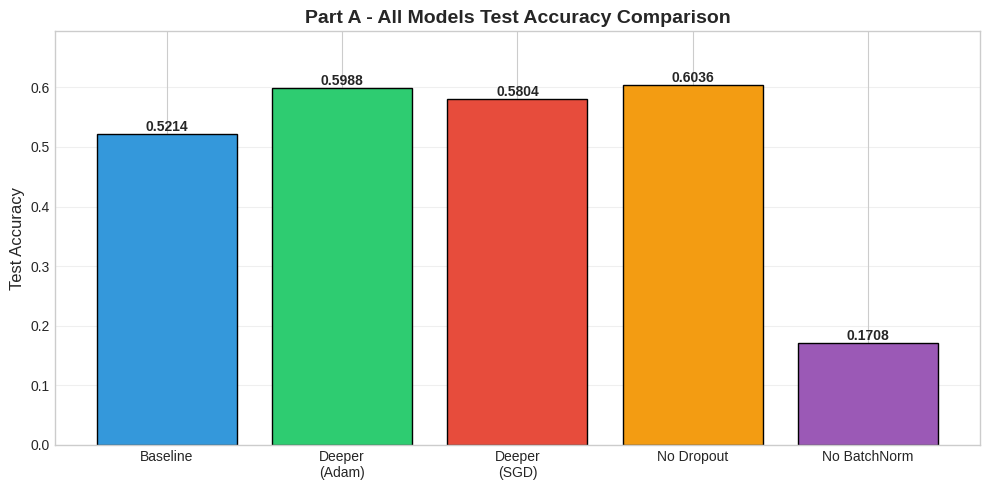

In [104]:
# Final comparison bar chart
fig, ax = plt.subplots(figsize=(10, 5))

model_names = ['Baseline', 'Deeper\n(Adam)', 'Deeper\n(SGD)', 'No Dropout', 'No BatchNorm']
model_accs = [baseline_test_acc, deeper_test_acc, sgd_test_acc, abl1_acc, abl2_acc]
colors_final = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

bars = ax.bar(model_names, model_accs, color=colors_final, edgecolor='black')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005, 
            f'{bar.get_height():.4f}', ha='center', fontweight='bold', fontsize=10)

ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('Part A - All Models Test Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_ylim(0, max(model_accs) * 1.15)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 5.6 Part A Summary

**Key Findings:**
- Deeper architecture with regularization generally improves over the baseline
- BatchNormalization stabilizes training and improves convergence
- Dropout helps prevent overfitting, especially in fully connected layers
- Adam optimizer typically converges faster than SGD for this task
- Class imbalance remains a challenge, particularly for 'disgust' class

**Challenges Faced:**
- Overfitting: the gap between training and validation accuracy
- Class imbalance: underrepresented classes (disgust) have lower accuracy
- Computational cost increases significantly with deeper models
- Finding the right balance between model complexity and generalization

## 6. Part B: Fine-Tuning a Pre-Trained Model (Transfer Learning)

Transfer learning leverages pre-trained model weights from ImageNet to boost performance on our facial expression dataset. This is especially useful when:
- Dataset is relatively small
- Training from scratch is computationally expensive
- Pre-trained models have already learned rich feature representations

**Model chosen: VGG16** — well-suited for image classification tasks with a clear, sequential architecture.

### 6.1 Prepare Data for Transfer Learning

**Key adjustments needed:**
- VGG16 expects **224×224 RGB** input, but our images are **48×48 grayscale**
- Images will be resized to 224×224 and converted to 3-channel (RGB)

In [105]:
# Transfer learning constants — global batch size scales with GPU replicas
TL_IMG_SIZE    = (224, 224)
TL_INPUT_SHAPE = (224, 224, 3)

# 64 images per GPU is optimal for 224×224 FP16 on T4/P100.
# MirroredStrategy sums gradients across replicas, so effective batch = 64 × N_gpus.
TL_BATCH_SIZE = 64 * strategy.num_replicas_in_sync

print("Transfer Learning — Constants")
print(f"  Replicas (GPUs/TPUs) : {strategy.num_replicas_in_sync}")
print(f"  Batch size per GPU   : 64")
print(f"  Global batch size    : {TL_BATCH_SIZE}")
print(f"  Input shape          : {TL_INPUT_SHAPE}")
print(f"  Color mode           : rgb (48×48 grayscale → 224×224 rgb)")


Transfer Learning — Constants
  Replicas (GPUs/TPUs) : 2
  Batch size per GPU   : 64
  Global batch size    : 128
  Input shape          : (224, 224, 3)
  Color mode           : rgb (48×48 grayscale → 224×224 rgb)


In [106]:
# Training data generator with augmentation
tl_train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1,
    shear_range=0.1,
    fill_mode='nearest'
)

tl_train_generator = tl_train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=TL_IMG_SIZE,
    batch_size=TL_BATCH_SIZE,
    color_mode='rgb',
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

TL_TRAIN_STEPS = len(tl_train_generator)

# Wrap in tf.data so Keras 3 can prefetch batches asynchronously while GPU trains
tl_train_ds = tf.data.Dataset.from_generator(
    lambda: tl_train_generator,
    output_signature=(
        tf.TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None, NUM_CLASSES), dtype=tf.float32)
    )
).prefetch(tf.data.AUTOTUNE)

print(f"Train: {tl_train_generator.samples} images, {TL_TRAIN_STEPS} steps/epoch")


Found 47243 images belonging to 7 classes.
Train: 47243 images, 370 steps/epoch


In [107]:
# Validation data generator
tl_val_datagen = ImageDataGenerator(rescale=1./255)

tl_val_generator = tl_val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=TL_IMG_SIZE,
    batch_size=TL_BATCH_SIZE,
    color_mode='rgb',
    class_mode='categorical',
    shuffle=False,
    seed=SEED
)

TL_VAL_STEPS = len(tl_val_generator)

tl_val_ds = tf.data.Dataset.from_generator(
    lambda: tl_val_generator,
    output_signature=(
        tf.TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None, NUM_CLASSES), dtype=tf.float32)
    )
).prefetch(tf.data.AUTOTUNE)

print(f"Val: {tl_val_generator.samples} images, {TL_VAL_STEPS} steps/epoch")


Found 6503 images belonging to 7 classes.
Val: 6503 images, 51 steps/epoch


In [108]:
# Test data generator
tl_test_datagen = ImageDataGenerator(rescale=1./255)

tl_test_generator = tl_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=TL_IMG_SIZE,
    batch_size=TL_BATCH_SIZE,
    color_mode='rgb',
    class_mode='categorical',
    shuffle=False,
    seed=SEED
)

TL_TEST_STEPS = len(tl_test_generator)

tl_test_ds = tf.data.Dataset.from_generator(
    lambda: tl_test_generator,
    output_signature=(
        tf.TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None, NUM_CLASSES), dtype=tf.float32)
    )
).prefetch(tf.data.AUTOTUNE)

print(f"Test: {tl_test_generator.samples} images, {TL_TEST_STEPS} steps/epoch")


Found 1680 images belonging to 7 classes.
Test: 1680 images, 14 steps/epoch


### 6.2 Load and Adapt VGG16 Pre-Trained Model

In [109]:
# Load VGG16 for architecture inspection (diagnostic only).
# The model used for training is re-created inside strategy.scope() in the next
# build cell so that all layer variables are registered as MirroredVariables.
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=TL_INPUT_SHAPE
)

print("VGG16 loaded for diagnostic inspection.")
print(f"  Total layers     : {len(base_model.layers)}")
print(f"  Total parameters : {base_model.count_params():,}")


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
VGG16 loaded for diagnostic inspection.
  Total layers     : 19
  Total parameters : 14,714,688


In [110]:
# Print VGG16 base architecture
base_model.summary()

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

In [111]:
# Build transfer learning model inside strategy.scope().
# VGG16 is re-loaded here so every layer variable is created as a
# MirroredVariable — required for MirroredStrategy to replicate gradients
# across all GPUs. The weights are already cached locally (no re-download).
from tensorflow.keras.models import Model

with strategy.scope():
    base_model = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=TL_INPUT_SHAPE
    )

    # Phase 1: freeze all VGG16 layers, train only the custom head
    for layer in base_model.layers:
        layer.trainable = False

    # Custom classification head
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    # float32 on the output layer is mandatory with mixed_float16 — softmax
    # operates on float16 values which saturate to inf, producing NaN losses.
    output = Dense(NUM_CLASSES, activation='softmax', dtype='float32')(x)

    tl_model = Model(inputs=base_model.input, outputs=output)

print("Transfer learning model built inside strategy scope.")
print(f"  Replicas            : {strategy.num_replicas_in_sync}")
print(f"  Output dtype        : float32  (mixed-precision safe)")
print(f"  VGG16 base          : FROZEN")
print(f"  Custom head         : TRAINABLE")


Transfer learning model built inside strategy scope.
  Replicas            : 2
  Output dtype        : float32  (mixed-precision safe)
  VGG16 base          : FROZEN
  Custom head         : TRAINABLE


In [112]:
# Print full model summary
tl_model.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 256)            │       131,32

 Total params: 15,113,543 (57.65 MB)

 Trainable params: 397,319 (1.52 MB)

 Non-trainable params: 14,716,224 (56.14 MB)

In [113]:
# Show trainable vs frozen layers
trainable_count = sum(1 for layer in tl_model.layers if layer.trainable)
frozen_count = sum(1 for layer in tl_model.layers if not layer.trainable)
trainable_params = sum(tf.keras.backend.count_params(w) for w in tl_model.trainable_weights)
non_trainable_params = sum(tf.keras.backend.count_params(w) for w in tl_model.non_trainable_weights)

print("Layer Status:")
print(f"  Frozen layers (VGG16 base): {frozen_count}")
print(f"  Trainable layers (custom head): {trainable_count}")
print(f"  Trainable parameters: {trainable_params:,}")
print(f"  Non-trainable parameters: {non_trainable_params:,}")
print(f"  Total parameters: {tl_model.count_params():,}")

Layer Status:
  Frozen layers (VGG16 base): 19
  Trainable layers (custom head): 8
  Trainable parameters: 397,319
  Non-trainable parameters: 14,716,224
  Total parameters: 15,113,543


### 6.3 Phase 1: Feature Extraction (Frozen Base)

In [114]:
# Compile — Phase 1 (feature extraction, frozen VGG16 base).
# Note: jit_compile=True is intentionally omitted. mixed_float16 wraps the
# optimizer in LossScaleOptimizer which calls ops.cond() for gradient finite-
# checking. That cond() issues a merge_call() inside MirroredStrategy.run(),
# which TF forbids inside a nested tf.function / XLA graph — causing a
# RuntimeError on the first training step. mixed_float16 alone already gives
# ~1.5-2× throughput from Tensor Cores; XLA is not needed on top of that.
with strategy.scope():
    tl_model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )

print("Model compiled — Phase 1 (feature extraction)")
print(f"  Optimizer  : Adam  lr=1e-3")
print(f"  Precision  : mixed_float16 (Tensor Core acceleration)")
print(f"  Trainable  : custom head only")

Model compiled — Phase 1 (feature extraction)
  Optimizer  : Adam  lr=1e-3
  Precision  : mixed_float16 (Tensor Core acceleration)
  Trainable  : custom head only


In [115]:
# Train Phase 1: Feature Extraction (frozen VGG16, custom head only)
EPOCHS_FE = 20

early_stopping_fe = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_fe = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

print(f"Phase 1: Feature Extraction — up to {EPOCHS_FE} epochs")
print(f"  VGG16 base : FROZEN  |  Head : TRAINABLE")
print(f"  Batch size : {TL_BATCH_SIZE}  |  Data : tf.data pipeline with AUTOTUNE prefetch")
print()

start_time_fe = time.time()

fe_history = tl_model.fit(
    tl_train_ds,
    steps_per_epoch=TL_TRAIN_STEPS,
    epochs=EPOCHS_FE,
    validation_data=tl_val_ds,
    validation_steps=TL_VAL_STEPS,
    callbacks=[early_stopping_fe, reduce_lr_fe],
    class_weight=class_weights,
    verbose=1
)

fe_train_time = time.time() - start_time_fe
print(f"\nPhase 1 done: {fe_train_time:.1f}s  ({fe_train_time/60:.1f} min)")
print(f"Best val accuracy: {max(fe_history.history['val_accuracy']):.4f}")


Phase 1: Feature Extraction — up to 20 epochs
  VGG16 base : FROZEN  |  Head : TRAINABLE
  Batch size : 128  |  Data : tf.data pipeline with AUTOTUNE prefetch

Epoch 1/20


I0000 00:00:1778482692.257362     136 cuda_dnn.cc:529] Loaded cuDNN version 91002


370/370 ━━━━━━━━━━━━━━━━━━━━ 512s 1s/step - accuracy: 0.2475 - loss: 2.3160 - val_accuracy: 0.3242 - val_loss: 1.7478 - learning_rate: 0.0010
Epoch 2/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 490s 1s/step - accuracy: 0.3477 - loss: 1.6861 - val_accuracy: 0.3211 - val_loss: 1.7290 - learning_rate: 0.0010
Epoch 3/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 492s 1s/step - accuracy: 0.3771 - loss: 1.6047 - val_accuracy: 0.3375 - val_loss: 1.7315 - learning_rate: 0.0010
Epoch 4/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 494s 1s/step - accuracy: 0.3946 - loss: 1.5708 - val_accuracy: 0.3926 - val_loss: 1.5494 - learning_rate: 0.0010
Epoch 5/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 496s 1s/step - accuracy: 0.4028 - loss: 1.5456 - val_accuracy: 0.3937 - val_loss: 1.5576 - learning_rate: 0.0010
Epoch 7/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4002 - loss: 1.5436
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
370/370 ━━━━━━━━━━━━━━━━━━━━ 501s 1s/step - accuracy: 0.4002 - loss: 1.5436 - val_acc

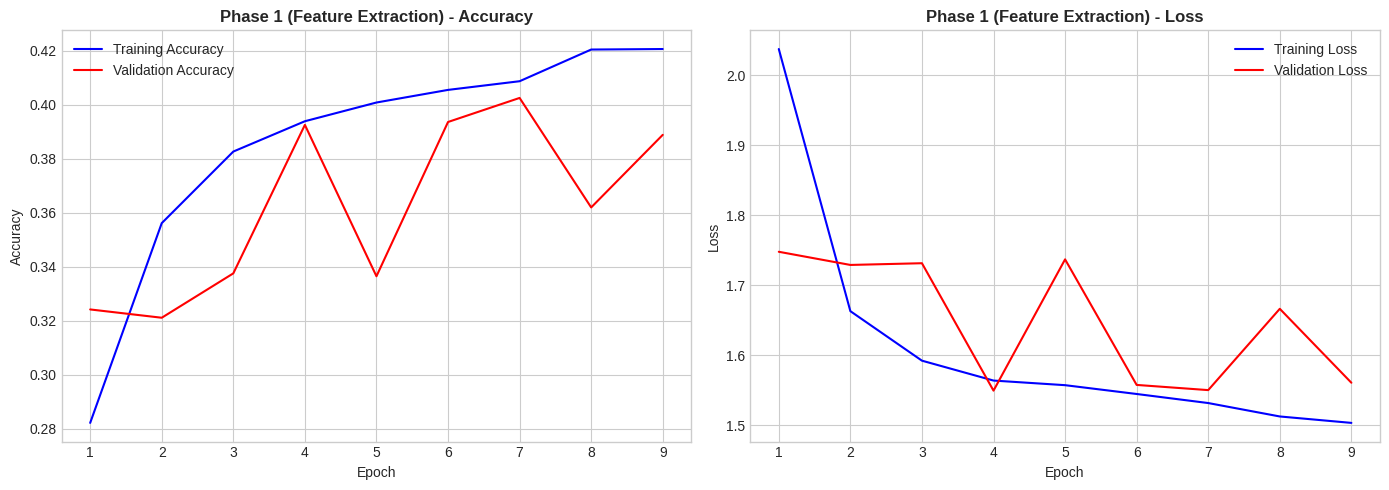

Phase 1 Best Validation Accuracy: 0.4026


In [116]:
# Phase 1 training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_fe = range(1, len(fe_history.history['accuracy']) + 1)

axes[0].plot(epochs_fe, fe_history.history['accuracy'], 'b-', label='Training Accuracy')
axes[0].plot(epochs_fe, fe_history.history['val_accuracy'], 'r-', label='Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Phase 1 (Feature Extraction) - Accuracy', fontweight='bold')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_fe, fe_history.history['loss'], 'b-', label='Training Loss')
axes[1].plot(epochs_fe, fe_history.history['val_loss'], 'r-', label='Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Phase 1 (Feature Extraction) - Loss', fontweight='bold')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"Phase 1 Best Validation Accuracy: {max(fe_history.history['val_accuracy']):.4f}")

### 6.4 Phase 2: Fine-Tuning (Unfreeze Top Layers)

In [117]:
# Phase 2 setup: unfreeze VGG16 block5 for fine-tuning.
#
# BUG FIX: trainability must be modified inside strategy.scope() so the
# MirroredStrategy distributed variable graph sees the updated trainable set
# BEFORE compile() re-traces the XLA execution graph in the next cell.
with strategy.scope():
    # Re-freeze the entire base (safety reset — head stays trainable)
    for layer in base_model.layers:
        layer.trainable = False

    # Unfreeze block5: conv1, conv2, conv3, pool (last 4 layers of VGG16 base)
    for layer in base_model.layers[-4:]:
        layer.trainable = True

# Report full layer status
print("Layer trainability after Phase 2 setup:")
print("-" * 52)
for layer in tl_model.layers:
    status = "TRAINABLE" if layer.trainable else "FROZEN   "
    print(f"  {layer.name:<28} {status}")


Layer trainability after Phase 2 setup:
----------------------------------------------------
  input_layer_6                FROZEN   
  block1_conv1                 FROZEN   
  block1_conv2                 FROZEN   
  block1_pool                  FROZEN   
  block2_conv1                 FROZEN   
  block2_conv2                 FROZEN   
  block2_pool                  FROZEN   
  block3_conv1                 FROZEN   
  block3_conv2                 FROZEN   
  block3_conv3                 FROZEN   
  block3_pool                  FROZEN   
  block4_conv1                 FROZEN   
  block4_conv2                 FROZEN   
  block4_conv3                 FROZEN   
  block4_pool                  FROZEN   
  block5_conv1                 TRAINABLE
  block5_conv2                 TRAINABLE
  block5_conv3                 TRAINABLE
  block5_pool                  TRAINABLE
  global_average_pooling2d     TRAINABLE
  dense_20                     TRAINABLE
  batch_normalization_27       TRAINABLE
  dro

In [118]:
# Recompile — Phase 2 (fine-tuning with block5 + head both trainable).
# Lower LR (10×) prevents large gradient updates from destroying ImageNet
# weights. jit_compile omitted for the same reason as Phase 1 compile.
with strategy.scope():
    tl_model.compile(
        optimizer=Adam(learning_rate=1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )

trainable_params_ft = sum(
    tf.keras.backend.count_params(w) for w in tl_model.trainable_weights
)
print("Model recompiled — Phase 2 (fine-tuning)")
print(f"  Optimizer         : Adam  lr=1e-4  (10× lower — avoids catastrophic forgetting)")
print(f"  Precision         : mixed_float16 (Tensor Core acceleration)")
print(f"  Trainable params  : {trainable_params_ft:,}")

Model recompiled — Phase 2 (fine-tuning)
  Optimizer         : Adam  lr=1e-4  (10× lower — avoids catastrophic forgetting)
  Precision         : mixed_float16 (Tensor Core acceleration)
  Trainable params  : 7,476,743


In [119]:
# Train Phase 2: Fine-Tuning (VGG16 block5 + custom head)
EPOCHS_FT = 20

early_stopping_ft = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_ft = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

print(f"Phase 2: Fine-Tuning — up to {EPOCHS_FT} epochs")
print(f"  VGG16 block5 : TRAINABLE  |  Head : TRAINABLE")
print(f"  Batch size   : {TL_BATCH_SIZE}  |  Data : tf.data pipeline with AUTOTUNE prefetch")
print()

start_time_ft = time.time()

ft_history = tl_model.fit(
    tl_train_ds,
    steps_per_epoch=TL_TRAIN_STEPS,
    epochs=EPOCHS_FT,
    validation_data=tl_val_ds,
    validation_steps=TL_VAL_STEPS,
    callbacks=[early_stopping_ft, reduce_lr_ft],
    class_weight=class_weights,
    verbose=1
)

ft_train_time = time.time() - start_time_ft
tl_total_time = fe_train_time + ft_train_time
print(f"\nPhase 2 done: {ft_train_time:.1f}s  ({ft_train_time/60:.1f} min)")
print(f"Total TL time: {tl_total_time:.1f}s  ({tl_total_time/60:.1f} min)")
print(f"Best val accuracy: {max(ft_history.history['val_accuracy']):.4f}")


Phase 2: Fine-Tuning — up to 20 epochs
  VGG16 block5 : TRAINABLE  |  Head : TRAINABLE
  Batch size   : 128  |  Data : tf.data pipeline with AUTOTUNE prefetch

Epoch 1/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 511s 1s/step - accuracy: 0.4423 - loss: 1.4596 - val_accuracy: 0.5287 - val_loss: 1.2209 - learning_rate: 1.0000e-04
Epoch 2/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 504s 1s/step - accuracy: 0.5388 - loss: 1.2102 - val_accuracy: 0.5082 - val_loss: 1.2685 - learning_rate: 1.0000e-04
Epoch 3/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 501s 1s/step - accuracy: 0.5893 - loss: 1.0855 - val_accuracy: 0.5579 - val_loss: 1.1915 - learning_rate: 1.0000e-04
Epoch 4/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 500s 1s/step - accuracy: 0.6210 - loss: 1.0041 - val_accuracy: 0.5962 - val_loss: 1.0820 - learning_rate: 1.0000e-04
Epoch 5/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 502s 1s/step - accuracy: 0.6491 - loss: 0.9373 - val_accuracy: 0.5851 - val_loss: 1.1308 - learning_rate: 1.0000e-04
Epoch 6/20
370/370 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - ac

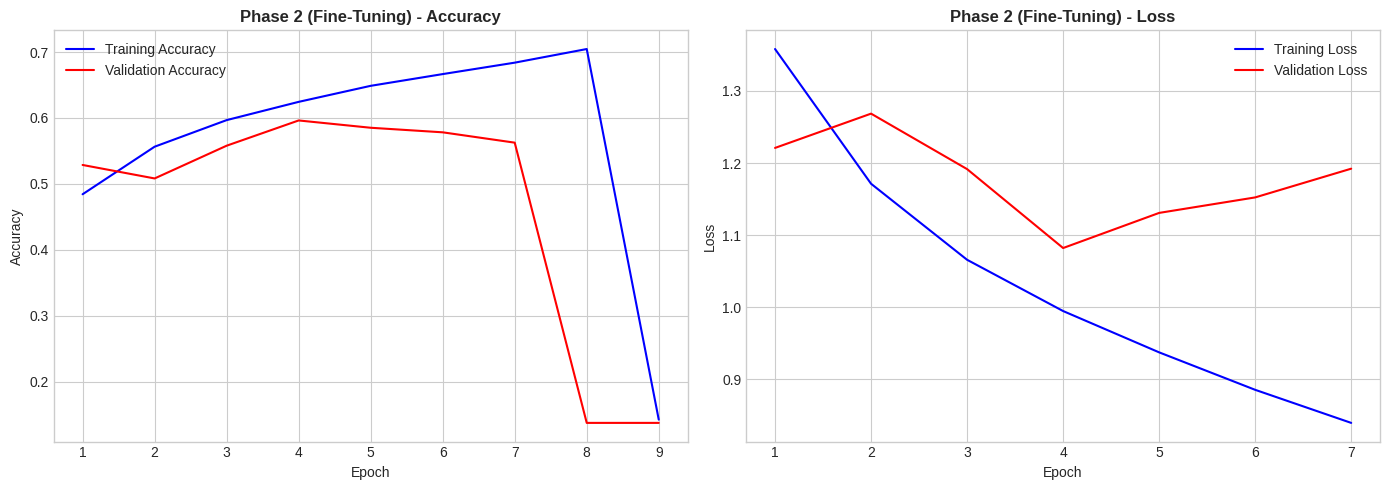

Phase 2 Best Validation Accuracy: 0.5962


In [120]:
# Phase 2 training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_ft = range(1, len(ft_history.history['accuracy']) + 1)

axes[0].plot(epochs_ft, ft_history.history['accuracy'], 'b-', label='Training Accuracy')
axes[0].plot(epochs_ft, ft_history.history['val_accuracy'], 'r-', label='Validation Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Phase 2 (Fine-Tuning) - Accuracy', fontweight='bold')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_ft, ft_history.history['loss'], 'b-', label='Training Loss')
axes[1].plot(epochs_ft, ft_history.history['val_loss'], 'r-', label='Validation Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Phase 2 (Fine-Tuning) - Loss', fontweight='bold')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"Phase 2 Best Validation Accuracy: {max(ft_history.history['val_accuracy']):.4f}")

### 6.5 Model Evaluation and Prediction

In [121]:
# Evaluate fine-tuned model on the held-out test set
tl_test_loss, tl_test_acc = tl_model.evaluate(
    tl_test_ds,
    steps=TL_TEST_STEPS,
    verbose=1
)

print(f"\nVGG16 Transfer Learning — Test Results")
print(f"  Test Accuracy : {tl_test_acc:.4f}")
print(f"  Test Loss     : {tl_test_loss:.4f}")


14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 262ms/step - accuracy: 0.4992 - loss: 1.2271

VGG16 Transfer Learning — Test Results
  Test Accuracy : 0.5321
  Test Loss     : 1.2548


In [122]:
# Generate predictions on the full test set
# Use the raw generator (not tf.data) so .classes is available for ground truth
tl_test_generator.reset()
tl_predictions = tl_model.predict(
    tl_test_generator,
    steps=TL_TEST_STEPS,
    verbose=1
)

# Trim padding from the last batch
tl_predictions  = tl_predictions[:tl_test_generator.samples]
tl_pred_classes = np.argmax(tl_predictions, axis=1)
tl_true_classes = tl_test_generator.classes

print(f"Predictions generated: {len(tl_pred_classes)} samples")


14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 214ms/step
Predictions generated: 1680 samples


In [123]:
# Classification report
print("Transfer Learning (VGG16) - Classification Report:")
print("=" * 60)
print(classification_report(tl_true_classes, tl_pred_classes, target_names=classes))

Transfer Learning (VGG16) - Classification Report:
              precision    recall  f1-score   support

       angry       0.45      0.61      0.51       276
     disgust       0.80      0.25      0.38        81
        fear       0.46      0.24      0.32       270
       happy       0.61      0.84      0.71       287
     neutral       0.52      0.59      0.55       279
         sad       0.46      0.36      0.41       287
    surprise       0.64      0.66      0.65       200

    accuracy                           0.53      1680
   macro avg       0.56      0.51      0.50      1680
weighted avg       0.53      0.53      0.51      1680



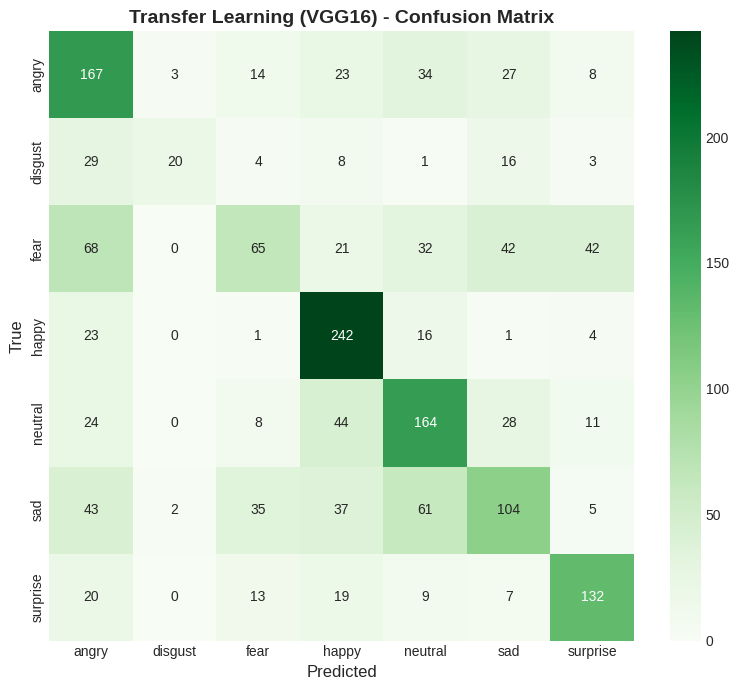

In [124]:
# Confusion matrix
cm_tl = confusion_matrix(tl_true_classes, tl_pred_classes)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Greens', xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('True', fontsize=12)
ax.set_title('Transfer Learning (VGG16) - Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [125]:
# Per-class accuracy
print("Transfer Learning (VGG16) - Per-Class Accuracy:")
print("-" * 40)
for i, cls in enumerate(classes):
    cls_mask = tl_true_classes == i
    cls_acc = np.mean(tl_pred_classes[cls_mask] == i)
    print(f"  {cls:<10}: {cls_acc:.4f} ({np.sum(cls_mask)} samples)")

Transfer Learning (VGG16) - Per-Class Accuracy:
----------------------------------------
  angry     : 0.6051 (276 samples)
  disgust   : 0.2469 (81 samples)
  fear      : 0.2407 (270 samples)
  happy     : 0.8432 (287 samples)
  neutral   : 0.5878 (279 samples)
  sad       : 0.3624 (287 samples)
  surprise  : 0.6600 (200 samples)


### 6.6 Inference on Sample Images

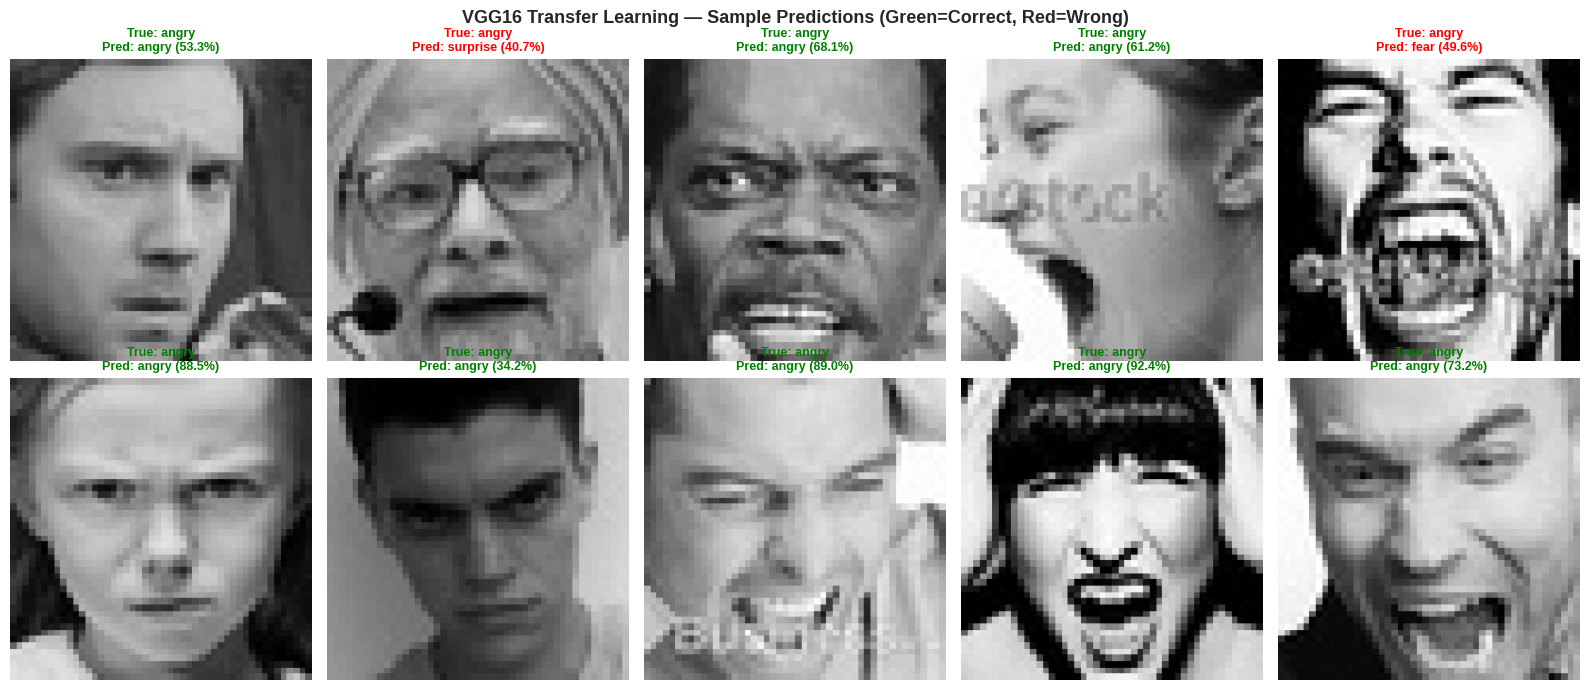

In [126]:
# Inference on 10 sample test images
fig, axes = plt.subplots(2, 5, figsize=(16, 7))

tl_test_generator.reset()
test_batch_tl, test_labels_tl = next(iter(tl_test_generator))

# Batch-predict all 10 images in one call — avoids 10 separate GPU round-trips
# and prevents MirroredStrategy from receiving a batch_size=1 that it can't split.
sample_preds = tl_model.predict(test_batch_tl[:10], verbose=0)

for i in range(10):
    row, col = i // 5, i % 5
    img = test_batch_tl[i]
    true_label = classes[np.argmax(test_labels_tl[i])]
    pred_label = classes[np.argmax(sample_preds[i])]
    confidence = np.max(sample_preds[i]) * 100

    axes[row, col].imshow(img)
    color = 'green' if pred_label == true_label else 'red'
    axes[row, col].set_title(
        f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)",
        fontsize=9, color=color, fontweight='bold'
    )
    axes[row, col].axis('off')

fig.suptitle(
    'VGG16 Transfer Learning — Sample Predictions (Green=Correct, Red=Wrong)',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()


### 6.7 Compare All Three Models: Baseline vs Deeper vs Transfer Learning

In [127]:
# Compute metrics for transfer learning model
tl_precision = precision_score(tl_true_classes, tl_pred_classes, average='weighted')
tl_recall = recall_score(tl_true_classes, tl_pred_classes, average='weighted')
tl_f1 = f1_score(tl_true_classes, tl_pred_classes, average='weighted')

print("=" * 75)
print("FINAL COMPARISON: ALL THREE MODELS")
print("=" * 75)
print(f"{'Metric':<25} {'Baseline':<15} {'Deeper':<15} {'VGG16 (TL)':<15}")
print("-" * 75)
print(f"{'Test Accuracy':<25} {baseline_test_acc:.4f}         {deeper_test_acc:.4f}         {tl_test_acc:.4f}")
print(f"{'Test Loss':<25} {baseline_test_loss:.4f}         {deeper_test_loss:.4f}         {tl_test_loss:.4f}")
print(f"{'Precision (weighted)':<25} {base_precision:.4f}         {deep_precision:.4f}         {tl_precision:.4f}")
print(f"{'Recall (weighted)':<25} {base_recall:.4f}         {deep_recall:.4f}         {tl_recall:.4f}")
print(f"{'F1-Score (weighted)':<25} {base_f1:.4f}         {deep_f1:.4f}         {tl_f1:.4f}")
print(f"{'Training Time':<25} {baseline_train_time:.1f}s          {deeper_train_time:.1f}s          {tl_total_time:.1f}s")
print(f"{'Parameters':<25} {baseline_model.count_params():,}     {deeper_model.count_params():,}   {tl_model.count_params():,}")
print("-" * 75)

all_accs = [baseline_test_acc, deeper_test_acc, tl_test_acc]
best_name = ['Baseline CNN', 'Deeper CNN', 'VGG16 Transfer Learning'][all_accs.index(max(all_accs))]
print(f"\nBest Overall Model: {best_name} ({max(all_accs):.4f} accuracy)")

FINAL COMPARISON: ALL THREE MODELS
Metric                    Baseline        Deeper          VGG16 (TL)     
---------------------------------------------------------------------------
Test Accuracy             0.5214         0.5988         0.5321
Test Loss                 1.4186         1.2022         1.2548
Precision (weighted)      0.5416         0.6110         0.5330
Recall (weighted)         0.5214         0.5988         0.5321
F1-Score (weighted)       0.5079         0.5906         0.5134
Training Time             731.6s          1102.2s          9017.1s
Parameters                1,314,183     6,035,655   15,113,543
---------------------------------------------------------------------------

Best Overall Model: Deeper CNN (0.5988 accuracy)


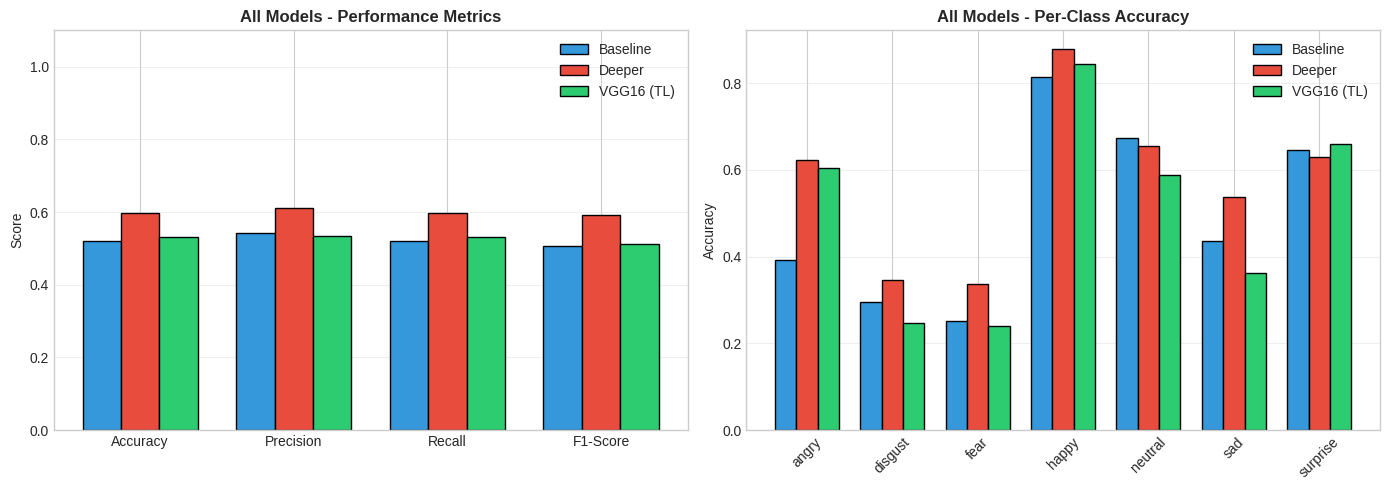

In [128]:
# Final bar chart: all three models
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy, Precision, Recall, F1
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
base_vals = [baseline_test_acc, base_precision, base_recall, base_f1]
deep_vals = [deeper_test_acc, deep_precision, deep_recall, deep_f1]
tl_vals = [tl_test_acc, tl_precision, tl_recall, tl_f1]

x = np.arange(len(metrics))
width = 0.25

axes[0].bar(x - width, base_vals, width, label='Baseline', color='#3498db', edgecolor='black')
axes[0].bar(x, deep_vals, width, label='Deeper', color='#e74c3c', edgecolor='black')
axes[0].bar(x + width, tl_vals, width, label='VGG16 (TL)', color='#2ecc71', edgecolor='black')
axes[0].set_ylabel('Score')
axes[0].set_title('All Models - Performance Metrics', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].set_ylim(0, 1.1)
axes[0].grid(axis='y', alpha=0.3)

# Per-class accuracy comparison
per_class_base = [np.mean(baseline_pred_classes[true_classes == i] == i) for i in range(NUM_CLASSES)]
per_class_deep = [np.mean(deeper_pred_classes[true_classes == i] == i) for i in range(NUM_CLASSES)]
per_class_tl = [np.mean(tl_pred_classes[tl_true_classes == i] == i) for i in range(NUM_CLASSES)]

x2 = np.arange(NUM_CLASSES)
axes[1].bar(x2 - width, per_class_base, width, label='Baseline', color='#3498db', edgecolor='black')
axes[1].bar(x2, per_class_deep, width, label='Deeper', color='#e74c3c', edgecolor='black')
axes[1].bar(x2 + width, per_class_tl, width, label='VGG16 (TL)', color='#2ecc71', edgecolor='black')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('All Models - Per-Class Accuracy', fontweight='bold')
axes[1].set_xticks(x2)
axes[1].set_xticklabels(classes, rotation=45)
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

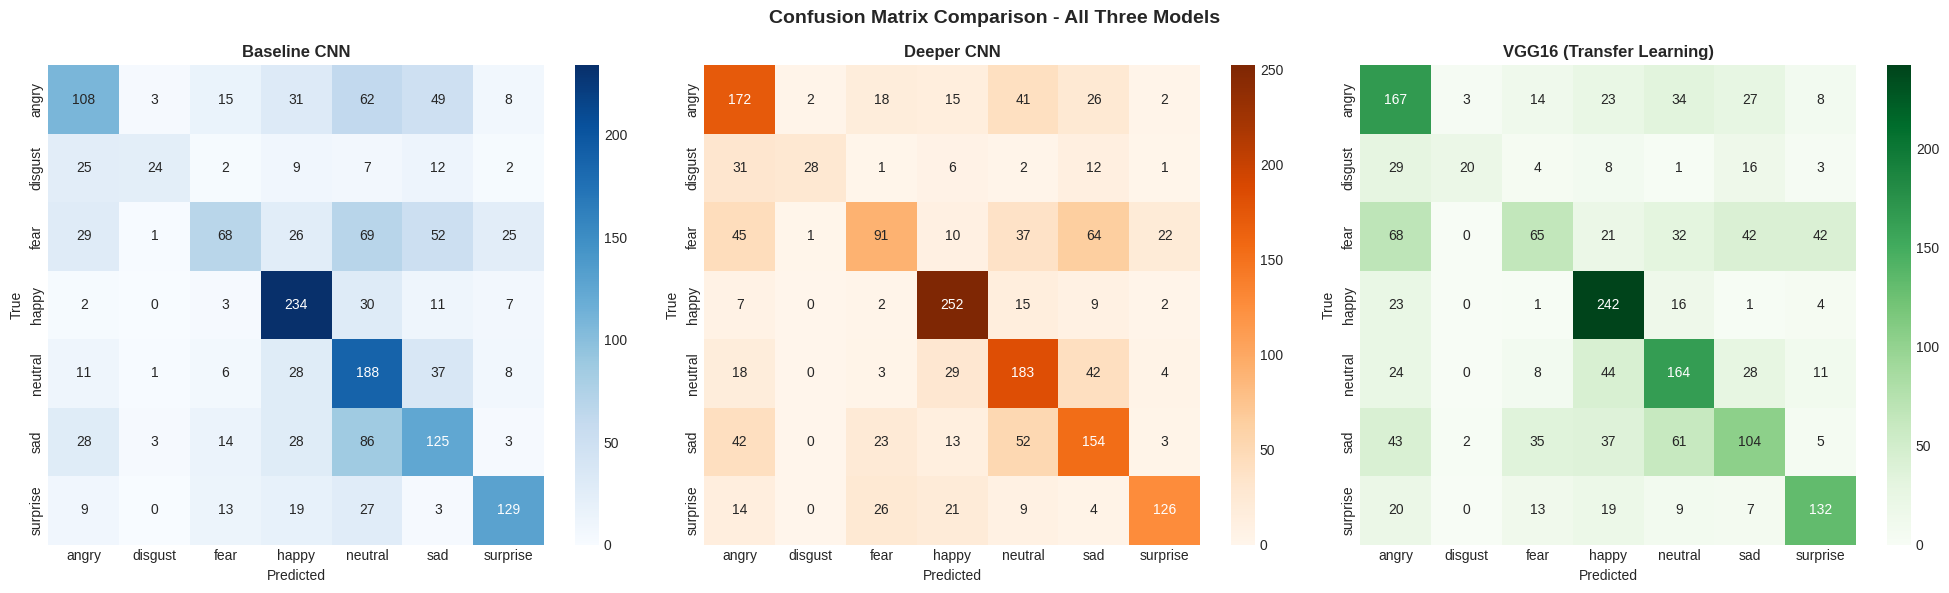

In [129]:
# Side-by-side confusion matrices for all three models
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

cm_base = confusion_matrix(true_classes, baseline_pred_classes)
cm_deep = confusion_matrix(true_classes, deeper_pred_classes)
cm_tl = confusion_matrix(tl_true_classes, tl_pred_classes)

sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes, ax=axes[0])
axes[0].set_title('Baseline CNN', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(cm_deep, annot=True, fmt='d', cmap='Oranges', xticklabels=classes, yticklabels=classes, ax=axes[1])
axes[1].set_title('Deeper CNN', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

sns.heatmap(cm_tl, annot=True, fmt='d', cmap='Greens', xticklabels=classes, yticklabels=classes, ax=axes[2])
axes[2].set_title('VGG16 (Transfer Learning)', fontweight='bold')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('True')

fig.suptitle('Confusion Matrix Comparison - All Three Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.8 Final Discussion

**Transfer Learning vs Training from Scratch:**
- VGG16 leverages pre-trained ImageNet features which capture low-level patterns (edges, textures) useful for facial expressions
- Feature extraction phase trains quickly since only the classification head is updated
- Fine-tuning with a lower learning rate allows the model to adapt without catastrophic forgetting
- The 48×48 grayscale to 224×224 RGB conversion adds computational overhead but gives access to powerful pre-trained features

**Key Takeaways:**
- Transfer learning is particularly effective when the dataset is small or class-imbalanced
- The trade-off between computational cost and accuracy determines the best model for deployment
- BatchNormalization and Dropout remain critical regularization techniques across all architectures
- Class imbalance (especially 'disgust') remains the biggest challenge across all models